# Cost & Token Breakdown: Prompt / Thinking / Generation

This notebook breaks down token usage and cost into three components:
- **Prompt** (input tokens)
- **Thinking** (reasoning tokens, part of completion)
- **Generation** (non-thinking output tokens = completion − thinking)

In [1]:
import json, os
import numpy as np
import pandas as pd
from pathlib import Path

In [2]:
# ── Paths ────────────────────────────────────────────────────────────
PROJECT_ROOT = Path(os.getcwd()).resolve()
if PROJECT_ROOT.name == 'analysis':
    PROJECT_ROOT = PROJECT_ROOT.parent

MODEL_INFO_PATH = PROJECT_ROOT / 'constant' / 'model_info.json'
EXPERIMENT_CONFIG_PATH = PROJECT_ROOT / 'constant' / 'experiment_config.json'
DATA_DIR = PROJECT_ROOT / 'data' / 'consolidated'

with open(MODEL_INFO_PATH) as f:
    model_info = json.load(f)
with open(EXPERIMENT_CONFIG_PATH) as f:
    exp_config = json.load(f)

PROVIDER_COLORS = exp_config.get('provider_colors', {})
price_lookup = {m['model_name']: m for m in model_info['models']}

In [3]:
def load_breakdown():
    """
    Build a DataFrame with per-model, per-dataset token & cost breakdown.

    Token categories:
      - prompt_tokens   (input)
      - thinking_tokens (reasoning, subset of completion)
      - generation_tokens = completion_tokens − thinking_tokens

    Cost categories (computed from listed prices):
      - prompt_cost     = prompt_tokens   × input_price  / 1e6
      - thinking_cost   = thinking_tokens × output_price / 1e6
      - generation_cost = generation_tokens × output_price / 1e6
    """
    datasets = exp_config['datasets']
    models   = exp_config['models']
    rows = []

    for model in models:
        model_name = model['model_name']
        short_name = model['short_name']
        provider   = model['provider']
        pricing    = price_lookup.get(model_name, {})
        in_price   = pricing.get('input_price_per_MTok')
        out_price  = pricing.get('output_price_per_MTok')

        for ds in datasets:
            fp = DATA_DIR / f"{ds['file_prefix']}-{model_name}.json"
            if not fp.exists():
                continue
            with open(fp) as f:
                data = json.load(f)

            prompt_tok  = data.get('prompt_tokens', 0)
            comp_tok    = data.get('completion_tokens', 0)
            think_tok   = sum(r.get('thinking_tokens', 0) for r in data.get('records', []))
            gen_tok     = comp_tok - think_tok
            counts      = data.get('counts', 0)
            perf        = data.get('performance', None)

            prompt_cost = prompt_tok * in_price / 1e6 if in_price else None
            think_cost  = think_tok  * out_price / 1e6 if out_price else None
            gen_cost    = gen_tok    * out_price / 1e6 if out_price else None
            total_cost  = (prompt_cost or 0) + (think_cost or 0) + (gen_cost or 0)

            rows.append({
                'model_name': model_name, 'short_name': short_name,
                'provider': provider,
                'dataset': ds['dataset_name'], 'category': ds.get('category', ''),
                'counts': counts, 'performance': perf,
                # Tokens
                'prompt_tokens': prompt_tok,
                'thinking_tokens': think_tok,
                'generation_tokens': gen_tok,
                'total_tokens': prompt_tok + comp_tok,
                # Costs
                'prompt_cost': prompt_cost,
                'thinking_cost': think_cost,
                'generation_cost': gen_cost,
                'total_cost': total_cost,
                # Prices
                'input_price': in_price,
                'output_price': out_price,
            })

    return pd.DataFrame(rows)

df_all = load_breakdown()
print(f'{len(df_all)} rows  ({df_all.short_name.nunique()} models × {df_all.dataset.nunique()} datasets)')
df_all.head(3)

72 rows  (8 models × 9 datasets)


,model_name,short_name,provider,dataset,category,counts,performance,prompt_tokens,thinking_tokens,generation_tokens,total_tokens,prompt_cost,thinking_cost,generation_cost,total_cost,input_price,output_price
0,gpt-5.2-high,GPT-5.2,OpenAI,aime,math,60,1.000,10101,388934,51683,450718,0.017677,5.445076,0.723562,6.186315,1.75,14.0
1,gpt-5.2-high,GPT-5.2,OpenAI,arc-agi-v1,reasoning,400,0.805,1355500,4596184,203437,6155121,2.372125,64.346576,2.848118,69.566819,1.75,14.0
2,gpt-5.2-high,GPT-5.2,OpenAI,arenahard,general,750,0.872,215513,1090308,898803,2204624,0.377148,15.264312,12.583242,28.224702,1.75,14.0


## 1. Per-Model Aggregate: Token & Cost Breakdown

In [4]:
# ── Aggregate across all datasets per model ─────────────────────────
agg = df_all.groupby(['model_name', 'short_name', 'provider']).agg(
    prompt_tokens    = ('prompt_tokens',    'sum'),
    thinking_tokens  = ('thinking_tokens',  'sum'),
    generation_tokens= ('generation_tokens','sum'),
    total_tokens     = ('total_tokens',     'sum'),
    prompt_cost      = ('prompt_cost',      'sum'),
    thinking_cost    = ('thinking_cost',    'sum'),
    generation_cost  = ('generation_cost',  'sum'),
    total_cost       = ('total_cost',       'sum'),
).reset_index()

# Token fractions
for col in ['prompt', 'thinking', 'generation']:
    agg[f'{col}_tok_pct'] = agg[f'{col}_tokens'] / agg['total_tokens'] * 100

# Cost fractions
for col in ['prompt', 'thinking', 'generation']:
    agg[f'{col}_cost_pct'] = agg[f'{col}_cost'] / agg['total_cost'] * 100

# Sort by total cost descending
agg = agg.sort_values('total_cost', ascending=False).reset_index(drop=True)

# Display token breakdown
tok_cols = ['short_name', 'provider',
            'prompt_tokens', 'thinking_tokens', 'generation_tokens', 'total_tokens',
            'prompt_tok_pct', 'thinking_tok_pct', 'generation_tok_pct']
agg[tok_cols].style.format({
    'prompt_tokens': '{:,.0f}', 'thinking_tokens': '{:,.0f}',
    'generation_tokens': '{:,.0f}', 'total_tokens': '{:,.0f}',
    'prompt_tok_pct': '{:.1f}%', 'thinking_tok_pct': '{:.1f}%',
    'generation_tok_pct': '{:.1f}%',
}).set_caption('Token Breakdown by Model (across all datasets)')

,short_name,provider,prompt_tokens,thinking_tokens,generation_tokens,total_tokens,prompt_tok_pct,thinking_tok_pct,generation_tok_pct
0,Gemini 3.1 Pro,Google,"3,850,819","91,876,957","4,877,191","100,604,967",3.8%,91.3%,4.8%
1,Claude Opus 4.6,Anthropic,"4,286,153","24,197,362","5,658,250","34,141,765",12.6%,70.9%,16.6%
2,Gemini 3 Flash,Google,"3,850,819","208,679,772","4,999,833","217,530,424",1.8%,95.9%,2.3%
3,GPT-5.2,OpenAI,"3,639,767","34,067,711","3,091,089","40,798,567",8.9%,83.5%,7.6%
4,Kimi K2.5,Moonshot AI,"3,753,119","91,596,524","4,324,330","99,673,973",3.8%,91.9%,4.3%
5,GPT-5 Mini,OpenAI,"3,751,688","23,151,246","2,848,949","29,751,883",12.6%,77.8%,9.6%
6,Claude Haiku 4.5,Anthropic,"4,076,953","24,308","6,502,795","10,604,056",38.4%,0.2%,61.3%
7,MiniMax-M2.5,MiniMax,"4,090,049","17,229,313","877,368","22,196,730",18.4%,77.6%,4.0%


In [5]:
# Display cost breakdown
cost_cols = ['short_name', 'provider',
             'prompt_cost', 'thinking_cost', 'generation_cost', 'total_cost',
             'prompt_cost_pct', 'thinking_cost_pct', 'generation_cost_pct']
agg[cost_cols].style.format({
    'prompt_cost': '${:.4f}', 'thinking_cost': '${:.4f}',
    'generation_cost': '${:.4f}', 'total_cost': '${:.4f}',
    'prompt_cost_pct': '{:.1f}%', 'thinking_cost_pct': '{:.1f}%',
    'generation_cost_pct': '{:.1f}%',
}).set_caption('Cost Breakdown by Model (across all datasets)')

,short_name,provider,prompt_cost,thinking_cost,generation_cost,total_cost,prompt_cost_pct,thinking_cost_pct,generation_cost_pct
0,Gemini 3.1 Pro,Google,$7.7016,$1102.5235,$58.5263,$1168.7514,0.7%,94.3%,5.0%
1,Claude Opus 4.6,Anthropic,$21.4308,$604.9340,$141.4562,$767.8211,2.8%,78.8%,18.4%
2,Gemini 3 Flash,Google,$1.9254,$626.0393,$14.9995,$642.9642,0.3%,97.4%,2.3%
3,GPT-5.2,OpenAI,$6.3696,$476.9480,$43.2752,$526.5928,1.2%,90.6%,8.2%
4,Kimi K2.5,Moonshot AI,$2.2519,$274.7896,$12.9730,$290.0144,0.8%,94.8%,4.5%
5,GPT-5 Mini,OpenAI,$0.9379,$46.3025,$5.6979,$52.9383,1.8%,87.5%,10.8%
6,Claude Haiku 4.5,Anthropic,$4.0770,$0.1215,$32.5140,$36.7125,11.1%,0.3%,88.6%
7,MiniMax-M2.5,MiniMax,$1.2270,$20.6752,$1.0528,$22.9550,5.3%,90.1%,4.6%


## 2. Stacked Bar Charts — Token & Cost Breakdown

In [6]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
from matplotlib.transforms import ScaledTranslation
from matplotlib.patches import Patch

# ═══════════════════════════════════════════════════════════════════════
# Nature-standard figure parameters
# ═══════════════════════════════════════════════════════════════════════
SINGLE_COL = 3.50   # inches  (89 mm)
DOUBLE_COL = 7.20   # inches (183 mm)

NATURE_RC = {
    'font.family':        'Helvetica Neue',
    'font.size':          7,
    'axes.titlesize':     8,
    'axes.labelsize':     7,
    'xtick.labelsize':    6,
    'ytick.labelsize':    7,
    'legend.fontsize':    6,
    'figure.dpi':         300,
    'savefig.dpi':        600,
    'axes.linewidth':     0.4,
    'xtick.major.width':  0.3,
    'ytick.major.width':  0.3,
    'xtick.major.size':   2.0,
    'ytick.major.size':   2.0,
    'xtick.major.pad':    2,
    'ytick.major.pad':    2,
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'legend.frameon':     False,
    'legend.handlelength': 0.8,
    'legend.handletextpad': 0.4,
    'legend.borderpad':   0.2,
    'legend.labelspacing': 0.3,
    'figure.constrained_layout.use': False,
    'pdf.fonttype':       42,
    'ps.fonttype':        42,
    'axes.facecolor':     'none',   # transparent axes background
    'figure.facecolor':   'none',   # transparent figure background
    'savefig.facecolor':  'none',   # transparent when saving
}
plt.rcParams.update(NATURE_RC)

PANEL_KW = dict(fontsize=8, fontweight='bold', va='bottom', ha='right')

# ═══════════════════════════════════════════════════════════════════════
# Provider-based shading: each model uses its provider color with
# three lightness levels for Prompt / Thinking / Generation.
# ═══════════════════════════════════════════════════════════════════════

def shade(hex_color, lightness_factor):
    """Blend *hex_color* toward white (factor > 1) or black (factor < 1).

    lightness_factor = 1.0  → original colour
    lightness_factor = 1.4  → lighter (mix with white)
    lightness_factor = 0.7  → darker  (mix with black)
    """
    rgb = mcolors.to_rgb(hex_color)
    if lightness_factor >= 1.0:
        t = 1 - 1 / lightness_factor
        rgb = tuple(c + (1 - c) * t for c in rgb)
    else:
        rgb = tuple(c * lightness_factor for c in rgb)
    return rgb


SHADE_PROMPT     = 1.55   # lightest
SHADE_GENERATION = 1.20   # medium
SHADE_THINKING   = 0.85   # darkest / most saturated


def provider_shades(provider):
    """Return (prompt_color, thinking_color, generation_color) for a provider."""
    base = PROVIDER_COLORS.get(provider, '#888888')
    return (
        shade(base, SHADE_PROMPT),
        shade(base, SHADE_THINKING),
        shade(base, SHADE_GENERATION),
    )


def _fmt_tokens(v):
    """Human-readable token count: 1.2M, 345K, etc."""
    if v >= 1e6:
        return f'{v/1e6:.1f}M'
    elif v >= 1e3:
        return f'{v/1e3:.0f}K'
    return f'{v:.0f}'


def _fmt_cost(v):
    """Dollar label: $1.2, $0.12, etc."""
    if v >= 1:
        return f'${v:.1f}'
    return f'${v:.2f}'


def draw_stacked_bar(ax, df, val_cols, labels, xlabel,
                     show_pct=True, total_col=None, pct_threshold=15,
                     min_width_frac=0.08, bar_h=0.55, annot_fs=5.5,
                     annot_mode='pct'):
    """Horizontal stacked bar with per-model provider-based shading.

    annot_mode: 'pct' (percentage), 'value' (formatted number),
                'cost' (dollar amount), or None to suppress annotations.
    """
    y = np.arange(len(df))
    n = len(df)

    row_colors = [provider_shades(prov) for prov in df['provider']]

    cum_lefts = []
    left = np.zeros(n)
    for seg_idx, (col, lab) in enumerate(zip(val_cols, labels)):
        vals = df[col].values.astype(float)
        cum_lefts.append(left.copy())
        for i in range(n):
            ax.barh(y[i], vals[i], left=left[i], height=bar_h,
                    color=row_colors[i][seg_idx],
                    edgecolor='white', linewidth=0.25)
        left = left + vals

    ax.set_yticks(y)
    ax.set_yticklabels(df['short_name'], fontsize=6.5)
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)

    # Annotations
    if annot_mode and total_col:
        totals = df[total_col].values.astype(float)
        max_total = totals.max()
        for bi, col in enumerate(val_cols):
            vals = df[col].values.astype(float)
            for i in range(n):
                pct = vals[i] / totals[i] * 100 if totals[i] > 0 else 0
                seg_frac = vals[i] / max_total if max_total > 0 else 0
                if pct >= pct_threshold and seg_frac >= min_width_frac:
                    x_pos = cum_lefts[bi][i] + vals[i] / 2
                    if annot_mode == 'pct':
                        txt = f'{pct:.0f}%'
                    elif annot_mode == 'value':
                        txt = _fmt_tokens(vals[i])
                    elif annot_mode == 'cost':
                        txt = _fmt_cost(vals[i])
                    else:
                        txt = f'{pct:.0f}%'
                    ax.text(x_pos, y[i], txt,
                            ha='center', va='center', fontsize=annot_fs,
                            color='white', fontweight='bold')

    # Legend
    grey = '#666666'
    legend_handles = [
        Patch(facecolor=shade(grey, SHADE_PROMPT),     edgecolor='white', linewidth=0.25, label='Prompt'),
        Patch(facecolor=shade(grey, SHADE_THINKING),   edgecolor='white', linewidth=0.25, label='Thinking'),
        Patch(facecolor=shade(grey, SHADE_GENERATION), edgecolor='white', linewidth=0.25, label='Generation'),
    ]
    ax.legend(handles=legend_handles, loc='lower right', frameon=False, ncol=1)

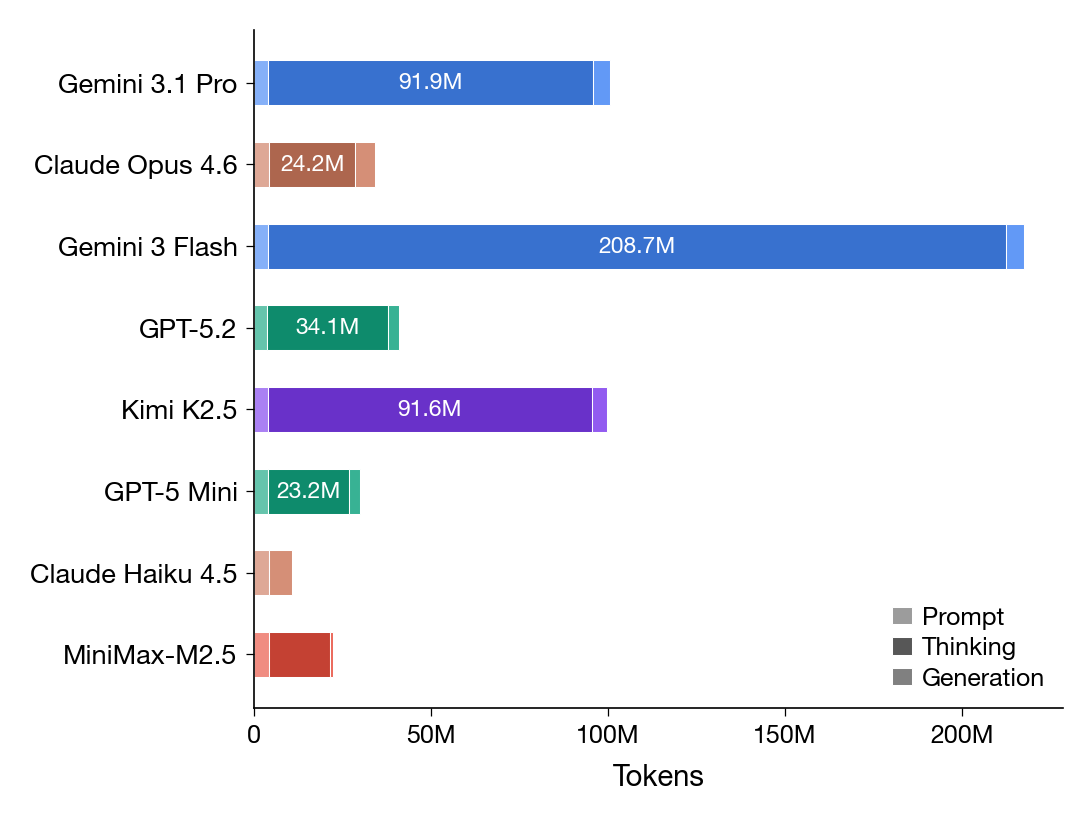

In [7]:
# ── Figure: Token Breakdown (single-column, Nature) ──────────────────
fig, ax = plt.subplots(figsize=(SINGLE_COL, 2.6))

draw_stacked_bar(
    ax, agg,
    val_cols=['prompt_tokens', 'thinking_tokens', 'generation_tokens'],
    labels=['Prompt', 'Thinking', 'Generation'],
    xlabel='Tokens',
    total_col='total_tokens',
    annot_mode='value',
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(
    lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else (f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}')
))
fig.patch.set_alpha(0)
plt.tight_layout(pad=0.3)
plt.show()

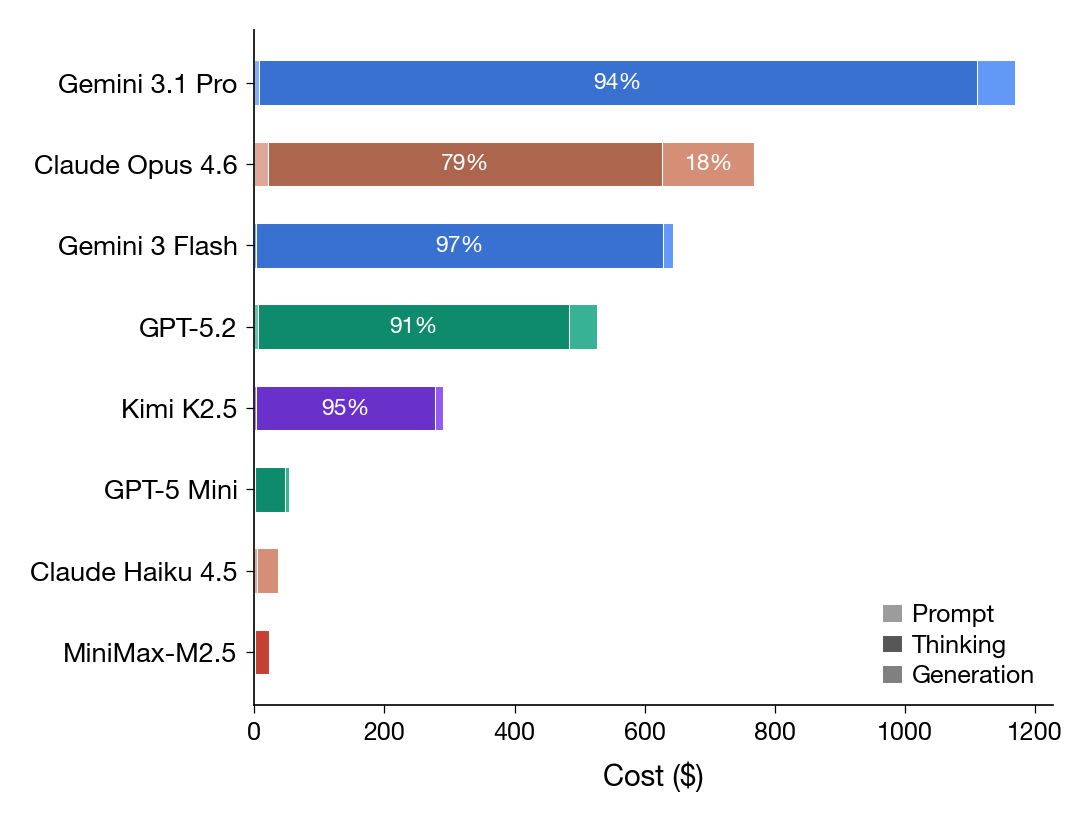

In [8]:
# ── Figure: Cost Breakdown (single-column, Nature) ───────────────────
fig, ax = plt.subplots(figsize=(SINGLE_COL, 2.6))

draw_stacked_bar(
    ax, agg,
    val_cols=['prompt_cost', 'thinking_cost', 'generation_cost'],
    labels=['Prompt', 'Thinking', 'Generation'],
    xlabel='Cost ($)',
    total_col='total_cost',
)
fig.patch.set_alpha(0)
plt.tight_layout(pad=0.3)
plt.show()

## 3. Combined Figure: Token & Cost Breakdown (Publication-Ready)

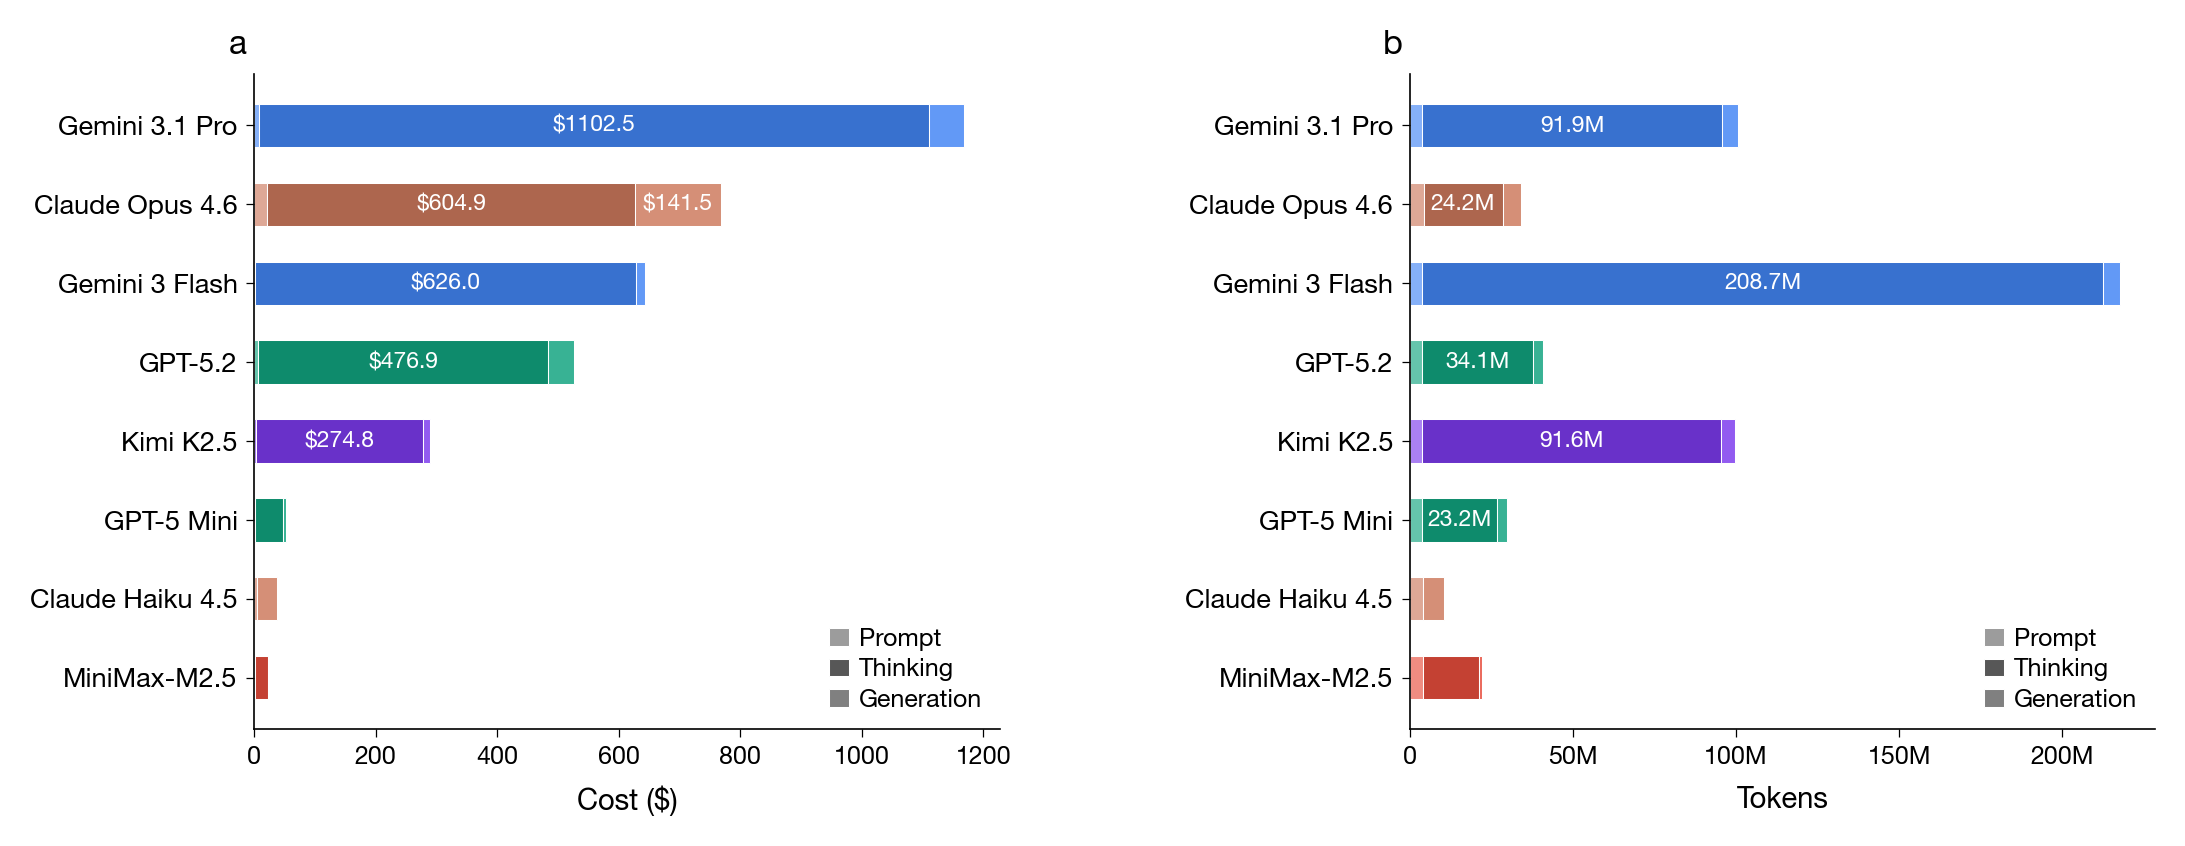

Saved to figure/token_cost_breakdown.{pdf,png}


In [9]:
# ═══════════════════════════════════════════════════════════════════════
# Combined Figure  (double-column width, Nature-ready)
# No titles — captions go in the manuscript.
# ═══════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(DOUBLE_COL, 2.8))
gs = gridspec.GridSpec(1, 2, wspace=0.55, left=0.10, right=0.98,
                       top=0.92, bottom=0.14)

# Panel (a): cost breakdown — show actual dollar values
ax_a = fig.add_subplot(gs[0])
draw_stacked_bar(
    ax_a, agg,
    val_cols=['prompt_cost', 'thinking_cost', 'generation_cost'],
    labels=['Prompt', 'Thinking', 'Generation'],
    xlabel='Cost ($)',
    total_col='total_cost',
    annot_mode='cost',
)
ax_a.text(-0.01, 1.02, 'a', transform=ax_a.transAxes, **PANEL_KW)

# Panel (b): token breakdown — show actual token values
ax_b = fig.add_subplot(gs[1])
draw_stacked_bar(
    ax_b, agg,
    val_cols=['prompt_tokens', 'thinking_tokens', 'generation_tokens'],
    labels=['Prompt', 'Thinking', 'Generation'],
    xlabel='Tokens',
    total_col='total_tokens',
    annot_mode='value',
)
ax_b.xaxis.set_major_formatter(plt.FuncFormatter(
    lambda x, _: f'{x/1e6:.0f}M' if x >= 1e6 else (f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}')
))
ax_b.text(-0.01, 1.02, 'b', transform=ax_b.transAxes, **PANEL_KW)

fig.patch.set_alpha(0)
fig.savefig(PROJECT_ROOT / 'figure' / 'token_cost_breakdown.pdf',
            bbox_inches='tight', pad_inches=0.01, facecolor='none')
fig.savefig(PROJECT_ROOT / 'figure' / 'token_cost_breakdown.png',
            bbox_inches='tight', pad_inches=0.01, facecolor='none', dpi=600)
plt.show()
print('Saved to figure/token_cost_breakdown.{pdf,png}')

## 4. Per-Dataset Breakdown

In [10]:
# ── Per-dataset token & cost breakdown (pivot table) ─────────────────
# Token fractions per dataset per model
df_all['think_tok_frac'] = df_all['thinking_tokens'] / (
    df_all['prompt_tokens'] + df_all['thinking_tokens'] + df_all['generation_tokens']
) * 100
df_all['think_cost_frac'] = df_all['thinking_cost'] / df_all['total_cost'] * 100

# Pivot: thinking token % by model × dataset
pivot_tok = df_all.pivot_table(
    index='short_name', columns='dataset',
    values='think_tok_frac'
).round(1)

pivot_tok.style.format('{:.1f}%').background_gradient(
    cmap='Reds', axis=None
).set_caption('Thinking Token % by Model × Dataset')

dataset,aime,arc-agi-v1,arenahard,gpqa,hle,livecodebench,livemathbench,mmlupro,simpleqa
short_name,,,,,,,,,
Claude Haiku 4.5,0.1%,0.0%,0.1%,0.2%,0.2%,0.1%,0.2%,0.3%,1.5%
Claude Opus 4.6,82.5%,62.2%,32.5%,78.2%,85.9%,66.1%,73.8%,50.2%,71.9%
GPT-5 Mini,86.3%,69.6%,52.0%,81.4%,88.1%,68.6%,82.3%,69.3%,92.1%
GPT-5.2,86.3%,74.7%,49.5%,83.8%,92.8%,79.6%,77.6%,57.7%,94.3%
Gemini 3 Flash,94.4%,88.2%,67.3%,95.2%,97.3%,97.5%,94.7%,96.9%,90.0%
Gemini 3.1 Pro,89.7%,76.0%,63.0%,86.6%,94.8%,87.4%,84.8%,81.6%,98.3%
Kimi K2.5,95.5%,84.3%,67.7%,94.3%,96.9%,90.6%,93.3%,88.1%,90.8%
MiniMax-M2.5,89.7%,37.2%,69.5%,84.8%,85.3%,72.3%,86.5%,74.7%,92.5%


In [11]:
# Pivot: thinking cost % by model × dataset
pivot_cost = df_all.pivot_table(
    index='short_name', columns='dataset',
    values='think_cost_frac'
).round(1)

pivot_cost.style.format('{:.1f}%').background_gradient(
    cmap='Reds', axis=None
).set_caption('Thinking Cost % by Model × Dataset')

dataset,aime,arc-agi-v1,arenahard,gpqa,hle,livecodebench,livemathbench,mmlupro,simpleqa
short_name,,,,,,,,,
Claude Haiku 4.5,0.2%,0.1%,0.1%,0.3%,0.3%,0.1%,0.2%,0.4%,1.9%
Claude Opus 4.6,84.8%,81.9%,35.1%,83.6%,89.3%,77.9%,77.4%,61.7%,81.0%
GPT-5 Mini,88.8%,90.5%,56.9%,88.1%,93.6%,82.7%,85.9%,81.0%,94.7%
GPT-5.2,88.0%,92.5%,54.1%,89.5%,95.6%,89.9%,80.7%,71.9%,96.3%
Gemini 3 Flash,95.1%,96.0%,72.0%,96.2%,98.3%,98.4%,95.4%,97.7%,91.4%
Gemini 3.1 Pro,90.8%,90.8%,67.1%,89.3%,96.2%,92.7%,86.4%,87.0%,98.6%
Kimi K2.5,96.2%,94.9%,71.1%,95.8%,98.1%,94.1%,94.4%,91.5%,92.1%
MiniMax-M2.5,96.0%,70.3%,78.7%,93.9%,95.5%,89.1%,92.5%,85.7%,95.8%


## 5. Heatmap: Thinking Token Share by Model × Dataset

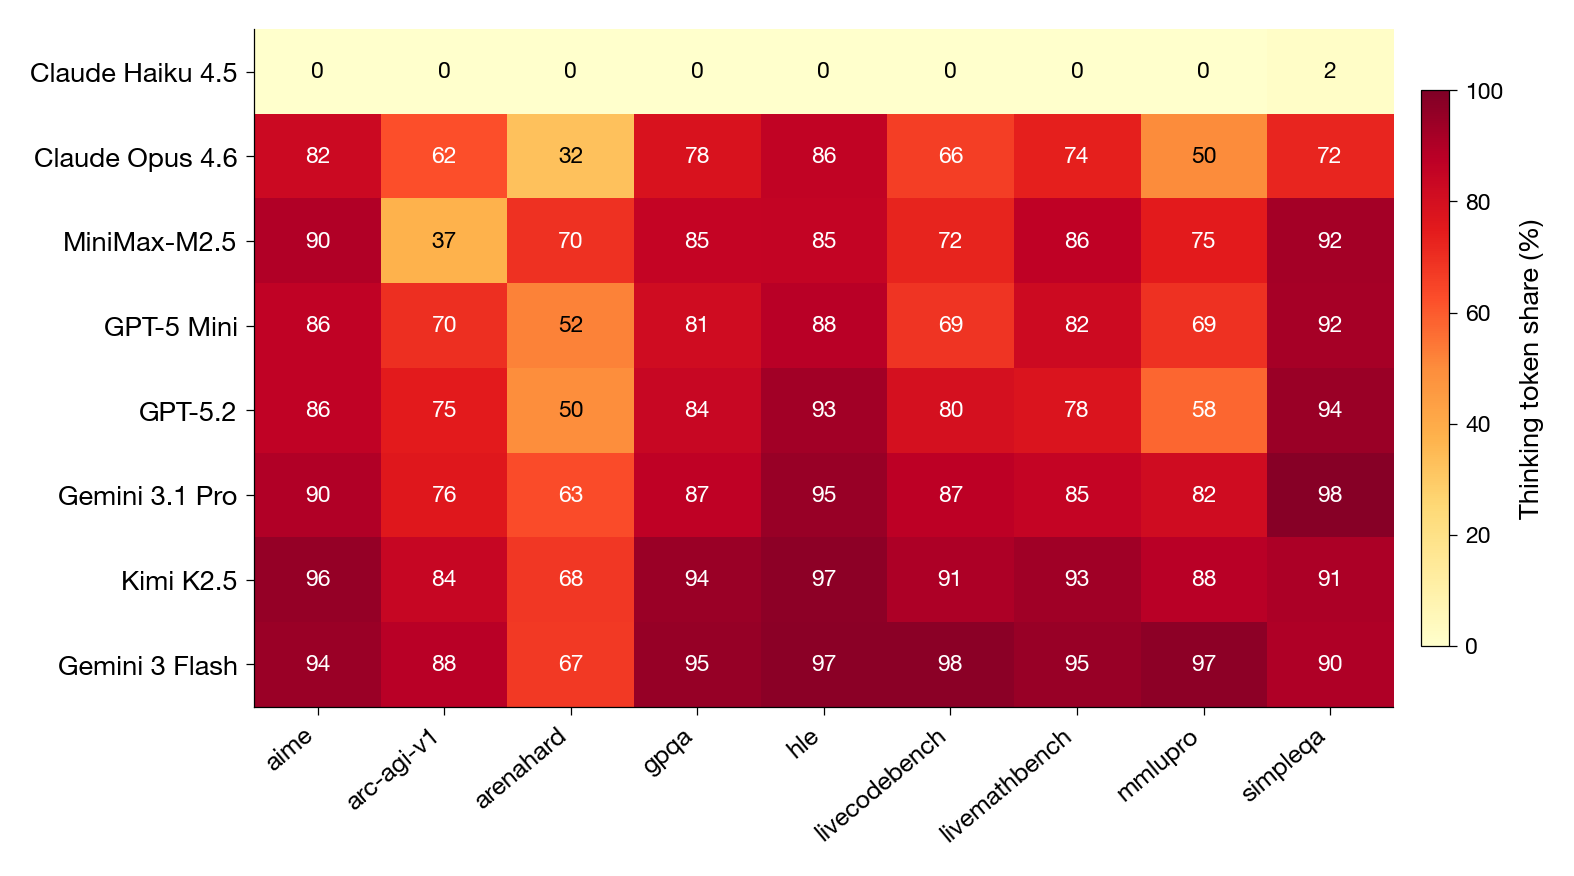

Saved to figure/thinking_token_heatmap.{pdf,png}


In [12]:
# ═══════════════════════════════════════════════════════════════════════
# Heatmap: Thinking Token Share  (double-column, Nature-ready)
# ═══════════════════════════════════════════════════════════════════════
# Re-order models by aggregate thinking %
model_order = agg.sort_values('thinking_tok_pct', ascending=True)['short_name'].tolist()
pivot_sorted = pivot_tok.reindex(model_order)

fig, ax = plt.subplots(figsize=(DOUBLE_COL * 0.75, 2.8))
im = ax.imshow(pivot_sorted.values, aspect='auto', cmap='YlOrRd',
               vmin=0, vmax=100)

ax.set_xticks(range(len(pivot_sorted.columns)))
ax.set_xticklabels(pivot_sorted.columns, rotation=40, ha='right', fontsize=6)
ax.set_yticks(range(len(pivot_sorted.index)))
ax.set_yticklabels(pivot_sorted.index, fontsize=6.5)

# Annotate each cell
for i in range(len(pivot_sorted.index)):
    for j in range(len(pivot_sorted.columns)):
        val = pivot_sorted.iloc[i, j]
        if pd.notna(val):
            text_color = 'white' if val > 55 else 'black'
            ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                    fontsize=5.5, color=text_color, fontweight='medium')

cbar = fig.colorbar(im, ax=ax, shrink=0.82, pad=0.02, aspect=20)
cbar.set_label('Thinking token share (%)', fontsize=6.5)
cbar.ax.tick_params(labelsize=5.5, width=0.3, length=2)
cbar.outline.set_linewidth(0.3)

# Thin cell borders
for spine in ax.spines.values():
    spine.set_linewidth(0.3)

fig.patch.set_alpha(0)
plt.tight_layout(pad=0.4)
fig.savefig(PROJECT_ROOT / 'figure' / 'thinking_token_heatmap.pdf',
            bbox_inches='tight', pad_inches=0.01, facecolor='none')
fig.savefig(PROJECT_ROOT / 'figure' / 'thinking_token_heatmap.png',
            bbox_inches='tight', pad_inches=0.01, facecolor='none', dpi=600)
plt.show()
print('Saved to figure/thinking_token_heatmap.{pdf,png}')

## 6. Per-Dataset Stacked Bars (All Models)

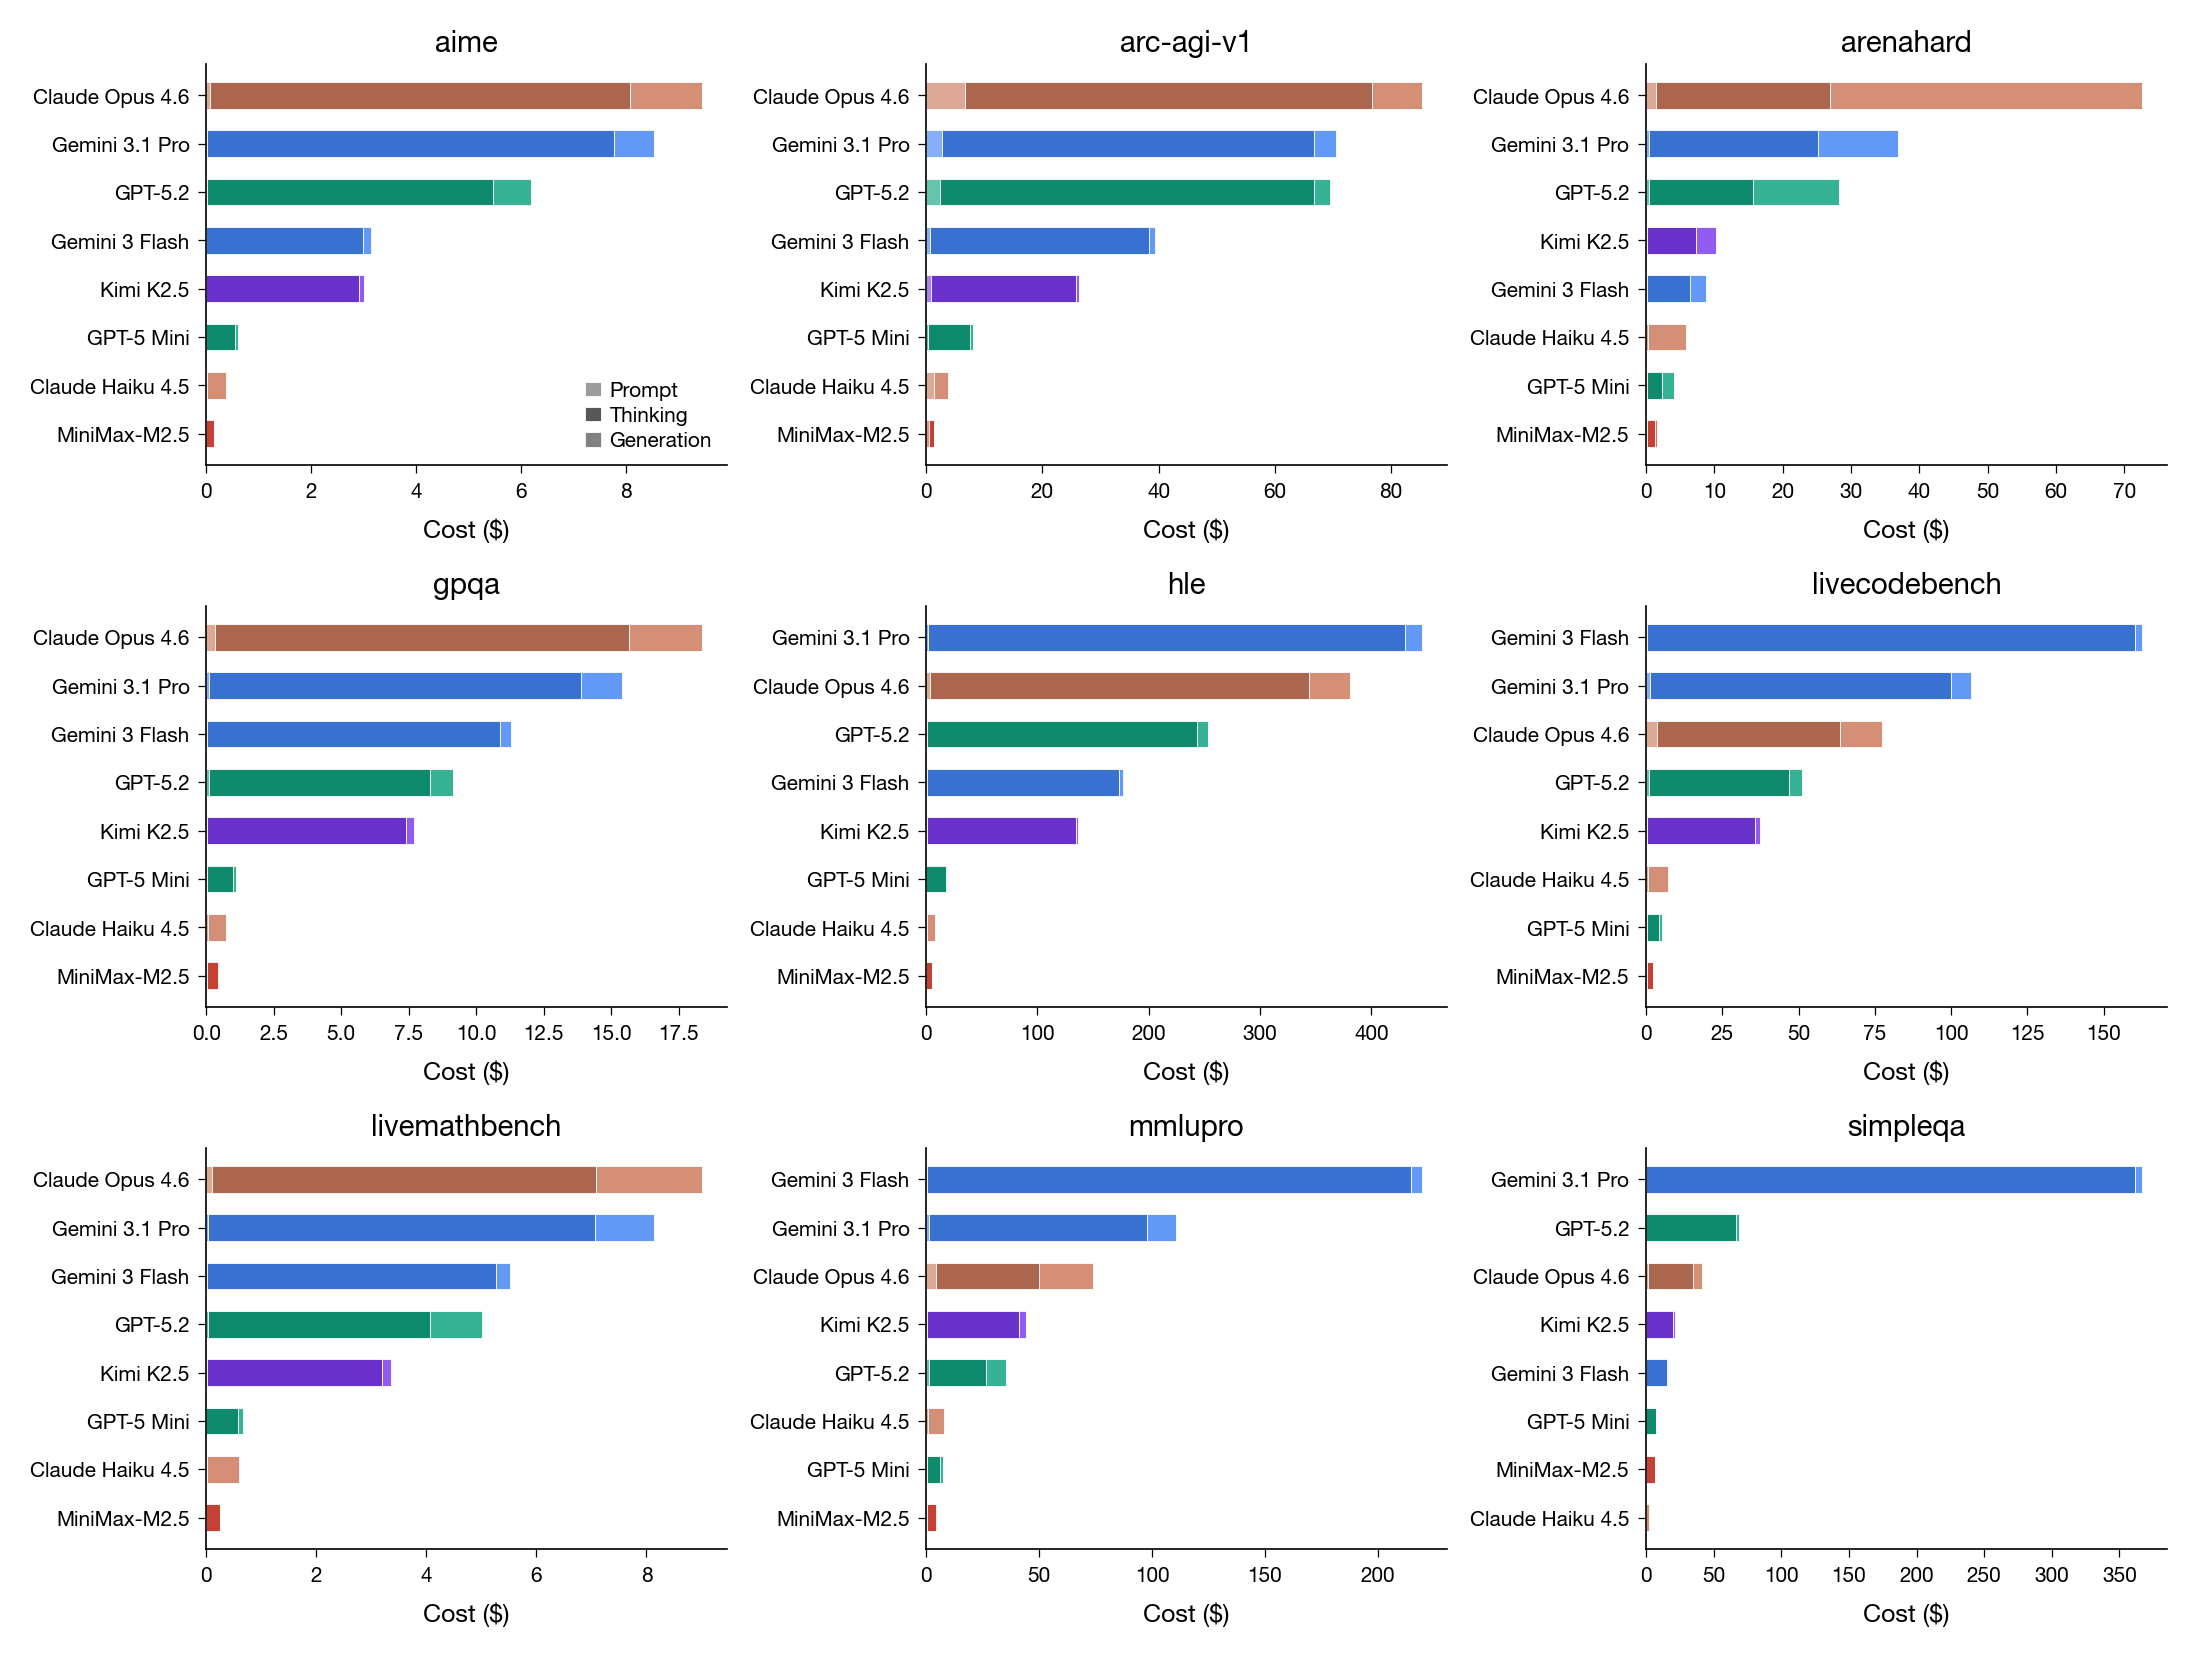

Saved to figure/cost_breakdown_by_dataset.{pdf,png}


In [13]:
# ═══════════════════════════════════════════════════════════════════════
# Per-dataset cost breakdown  (double-column, Nature-ready)
# ═══════════════════════════════════════════════════════════════════════
datasets = sorted(df_all['dataset'].unique())
n_ds = len(datasets)
n_cols = 3
n_rows = int(np.ceil(n_ds / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(DOUBLE_COL, n_rows * 1.8))
axes = axes.flatten()

for idx, ds_name in enumerate(datasets):
    ax = axes[idx]
    sub = df_all[df_all['dataset'] == ds_name].copy()
    sub = sub.sort_values('total_cost', ascending=False).reset_index(drop=True)

    y = np.arange(len(sub))
    left = np.zeros(len(sub))
    seg_cols = ['prompt_cost', 'thinking_cost', 'generation_cost']
    seg_labels = ['Prompt', 'Thinking', 'Generation']
    for seg_idx, (col, lab) in enumerate(zip(seg_cols, seg_labels)):
        vals = sub[col].values.astype(float)
        for i in range(len(sub)):
            prov = sub.iloc[i]['provider']
            c = provider_shades(prov)[seg_idx]
            ax.barh(y[i], vals[i], left=left[i], height=0.55,
                    color=c, edgecolor='white', linewidth=0.2)
        left += vals

    ax.set_yticks(y)
    ax.set_yticklabels(sub['short_name'], fontsize=5)
    ax.invert_yaxis()
    ax.set_title(ds_name, fontsize=7, fontweight='bold', pad=3)
    ax.set_xlabel('Cost ($)', fontsize=6)
    ax.tick_params(axis='x', labelsize=5)
    if idx == 0:
        grey = '#666666'
        legend_handles = [
            Patch(facecolor=shade(grey, SHADE_PROMPT),     edgecolor='white', linewidth=0.2, label='Prompt'),
            Patch(facecolor=shade(grey, SHADE_THINKING),   edgecolor='white', linewidth=0.2, label='Thinking'),
            Patch(facecolor=shade(grey, SHADE_GENERATION), edgecolor='white', linewidth=0.2, label='Generation'),
        ]
        ax.legend(handles=legend_handles, loc='lower right', frameon=False, fontsize=5)

# Hide unused subplots
for idx in range(n_ds, len(axes)):
    axes[idx].set_visible(False)

fig.patch.set_alpha(0)
plt.tight_layout(pad=0.4, h_pad=1.0, w_pad=0.8)
fig.savefig(PROJECT_ROOT / 'figure' / 'cost_breakdown_by_dataset.pdf',
            bbox_inches='tight', pad_inches=0.01, facecolor='none')
fig.savefig(PROJECT_ROOT / 'figure' / 'cost_breakdown_by_dataset.png',
            bbox_inches='tight', pad_inches=0.01, facecolor='none', dpi=600)
plt.show()
print('Saved to figure/cost_breakdown_by_dataset.{pdf,png}')

## 7. Case Study: Same Question, Vastly Different Token Usage

A concrete AIME example where two models both answer correctly, yet consume dramatically different amounts of thinking tokens.

In [35]:
# ═══════════════════════════════════════════════════════════════════════
# Case Study: AIME question #15 — both correct, 17.7× token difference
# ═══════════════════════════════════════════════════════════════════════
from IPython.display import display, Markdown, HTML

# Load records
_gpt_data = json.load(open(DATA_DIR / 'aime-hybrid-gpt-5.2-high.json'))
_gem_data = json.load(open(DATA_DIR / 'aime-hybrid-gemini-3-flash-preview.json'))
_gpt_rec = {r['index']: r for r in _gpt_data['records']}[3]
_gem_rec = {r['index']: r for r in _gem_data['records']}[3]

# Prices
_gpt_price = price_lookup['gpt-5.2-high']
_gem_price = price_lookup['gemini-3-flash-preview']

# Compute costs
_gpt_prompt_cost = _gpt_rec['prompt_tokens'] * _gpt_price['input_price_per_MTok'] / 1e6
_gpt_think_cost  = _gpt_rec['thinking_tokens'] * _gpt_price['output_price_per_MTok'] / 1e6
_gpt_gen_tok     = _gpt_rec['completion_tokens'] - _gpt_rec['thinking_tokens']
_gpt_gen_cost    = _gpt_gen_tok * _gpt_price['output_price_per_MTok'] / 1e6
_gpt_total_cost  = _gpt_prompt_cost + _gpt_think_cost + _gpt_gen_cost

_gem_prompt_cost = _gem_rec['prompt_tokens'] * _gem_price['input_price_per_MTok'] / 1e6
_gem_think_cost  = _gem_rec.get('thinking_tokens', 0) * _gem_price['output_price_per_MTok'] / 1e6
_gem_gen_tok     = _gem_rec['completion_tokens'] - _gem_rec.get('thinking_tokens', 0)
_gem_gen_cost    = _gem_gen_tok * _gem_price['output_price_per_MTok'] / 1e6
_gem_total_cost  = _gem_prompt_cost + _gem_think_cost + _gem_gen_cost

# ── Render ────────────────────────────────────────────────────────────
md = f"""
### Problem (AIME, index 15)

> {_gpt_rec['origin_query']}

**Answer: {_gpt_rec['ground_truth']}** — both models answered correctly.

---

### Token & Cost Comparison

| | **GPT-5.2** | **Gemini 3 Flash** | **Ratio** |
|---|---:|---:|---:|
| Prompt tokens | {_gpt_rec['prompt_tokens']:,} | {_gem_rec['prompt_tokens']:,} | {_gem_rec['prompt_tokens']/_gpt_rec['prompt_tokens']:.1f}× |
| Thinking tokens | {_gpt_rec['thinking_tokens']:,} | {_gem_rec.get('thinking_tokens',0):,} | {_gem_rec.get('thinking_tokens',0)/max(_gpt_rec['thinking_tokens'],1):.1f}× |
| Generation tokens | {_gpt_gen_tok:,} | {_gem_gen_tok:,} | {_gem_gen_tok/max(_gpt_gen_tok,1):.1f}× |
| **Total completion** | **{_gpt_rec['completion_tokens']:,}** | **{_gem_rec['completion_tokens']:,}** | **{_gem_rec['completion_tokens']/_gpt_rec['completion_tokens']:.1f}×** |
| Prompt cost | ${_gpt_prompt_cost:.6f} | ${_gem_prompt_cost:.6f} | |
| Thinking cost | ${_gpt_think_cost:.6f} | ${_gem_think_cost:.6f} | |
| Generation cost | ${_gpt_gen_cost:.6f} | ${_gem_gen_cost:.6f} | |
| **Total cost** | **${_gpt_total_cost:.6f}** | **${_gem_total_cost:.6f}** | **{_gem_total_cost/_gpt_total_cost:.1f}×** |

Gemini 3 Flash used **{_gem_rec['completion_tokens']/_gpt_rec['completion_tokens']:.1f}×** more completion tokens
and **{_gem_total_cost/_gpt_total_cost:.1f}×** more cost than GPT-5.2 on the same problem — both arriving at the correct answer **{_gpt_rec['ground_truth']}**.

---

### GPT-5.2 Response ({_gpt_rec['completion_tokens']:,} completion tokens)

{_gpt_rec['raw_output']}

---

### Gemini 3 Flash Response ({_gem_rec['completion_tokens']:,} completion tokens)

{_gem_rec['raw_output']}
"""

display(Markdown(md))


### Problem (AIME, index 15)

> Jen enters a lottery by picking $4$ distinct numbers from $S=\{1,2,3,\cdots,9,10\}.$ $4$ numbers are randomly chosen from $S.$ She wins a prize if at least two of her numbers were $2$ of the randomly chosen numbers, and wins the grand prize if all four of her numbers were the randomly chosen numbers. The probability of her winning the grand prize given that she won a prize is $\tfrac{m}{n}$ where $m$ and $n$ are relatively prime positive integers. Find $m+n$.

**Answer: 116** — both models answered correctly.

---

### Token & Cost Comparison

| | **GPT-5.2** | **Gemini 3 Flash** | **Ratio** |
|---|---:|---:|---:|
| Prompt tokens | 185 | 179 | 1.0× |
| Thinking tokens | 461 | 11,749 | 25.5× |
| Generation tokens | 562 | 586 | 1.0× |
| **Total completion** | **1,023** | **12,335** | **12.1×** |
| Prompt cost | $0.000324 | $0.000089 | |
| Thinking cost | $0.006454 | $0.035247 | |
| Generation cost | $0.007868 | $0.001758 | |
| **Total cost** | **$0.014646** | **$0.037095** | **2.5×** |

Gemini 3 Flash used **12.1×** more completion tokens
and **2.5×** more cost than GPT-5.2 on the same problem — both arriving at the correct answer **116**.

---

### GPT-5.2 Response (1,023 completion tokens)

Let Jen’s chosen set be a fixed set of 4 distinct numbers from \(\{1,2,\dots,10\}\). The lottery then draws 4 distinct numbers uniformly at random from the 10.

Let \(X\) be the number of matches between Jen’s 4 numbers and the 4 drawn numbers. Then
\[
\Pr(X=k)=\frac{\binom{4}{k}\binom{6}{4-k}}{\binom{10}{4}},
\]
since we choose \(k\) matching numbers from Jen’s 4, and the remaining \(4-k\) from the other 6 numbers.

Total outcomes:
\[
\binom{10}{4}=210.
\]

**Grand prize:** \(X=4\)
\[
\Pr(X=4)=\frac{\binom{4}{4}\binom{6}{0}}{210}=\frac{1}{210}.
\]

**Winning a (nonzero) prize:** \(X\ge 2\)
\[
\Pr(X\ge 2)=\Pr(X=2)+\Pr(X=3)+\Pr(X=4).
\]
Compute:
\[
\Pr(X=2)=\frac{\binom{4}{2}\binom{6}{2}}{210}=\frac{6\cdot 15}{210}=\frac{90}{210}=\frac{3}{7},
\]
\[
\Pr(X=3)=\frac{\binom{4}{3}\binom{6}{1}}{210}=\frac{4\cdot 6}{210}=\frac{24}{210}=\frac{4}{35},
\]
\[
\Pr(X=4)=\frac{1}{210}.
\]
So
\[
\Pr(X\ge 2)=\frac{3}{7}+\frac{4}{35}+\frac{1}{210}
=\frac{90}{210}+\frac{24}{210}+\frac{1}{210}
=\frac{115}{210}=\frac{23}{42}.
\]

Now the conditional probability is
\[
\Pr(X=4\mid X\ge 2)=\frac{\Pr(X=4)}{\Pr(X\ge 2)}
=\frac{\frac{1}{210}}{\frac{23}{42}}
=\frac{1}{210}\cdot\frac{42}{23}
=\frac{1}{115}.
\]
Thus \(\frac{m}{n}=\frac{1}{115}\), so \(m+n=1+115=116\).

\[
\boxed{116}
\]

---

### Gemini 3 Flash Response (12,335 completion tokens)

To find the probability of Jen winning the grand prize given that she won a prize, we first identify the total number of ways to choose 4 numbers from the set $S = \{1, 2, 3, \dots, 10\}$. This is given by the combination formula:
$$\binom{10}{4} = \frac{10 \times 9 \times 8 \times 7}{4 \times 3 \times 2 \times 1} = 210$$
Let $X$ be the number of Jen's numbers that match the randomly chosen numbers. The probability $P(X=k)$ is given by the hypergeometric distribution:
$$P(X=k) = \frac{\binom{4}{k} \binom{10-4}{4-k}}{\binom{10}{4}} = \frac{\binom{4}{k} \binom{6}{4-k}}{210}$$
Jen wins a prize if $X \ge 2$. The possible values for $X$ are 2, 3, and 4. We calculate the number of ways for each:
- For $X=2$: $\binom{4}{2} \binom{6}{2} = 6 \times 15 = 90$
- For $X=3$: $\binom{4}{3} \binom{6}{1} = 4 \times 6 = 24$
- For $X=4$: $\binom{4}{4} \binom{6}{0} = 1 \times 1 = 1$

The total number of ways to win a prize is $90 + 24 + 1 = 115$.
The probability of winning a prize is $P(X \ge 2) = \frac{115}{210}$.
Jen wins the grand prize if $X=4$. The probability of winning the grand prize is $P(X=4) = \frac{1}{210}$.
The probability of winning the grand prize given that she won a prize is:
$$P(X=4 | X \ge 2) = \frac{P(X=4)}{P(X \ge 2)} = \frac{1/210}{115/210} = \frac{1}{115}$$
This is in the form $\frac{m}{n}$ where $m=1$ and $n=115$. These are relatively prime positive integers.
Finally, we find $m+n$:
$$m+n = 1 + 115 = 116$$

\boxed{116}


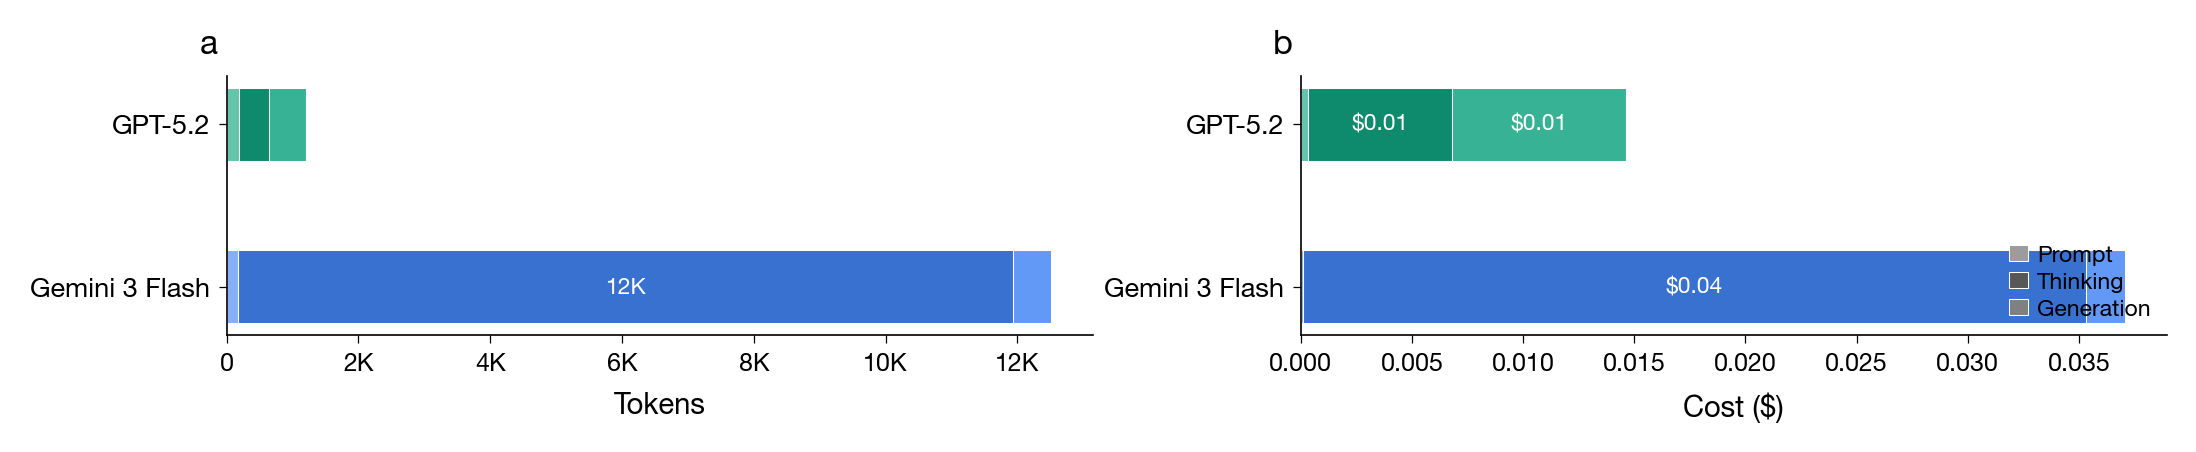

In [36]:
# ── Visual comparison: stacked bar for this single question ──────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(DOUBLE_COL, 1.4))

models_case = ['GPT-5.2', 'Gemini 3 Flash']
providers_case = ['OpenAI', 'Google']
y = np.arange(2)

# Token breakdown
tok_data = {
    'prompt':     [_gpt_rec['prompt_tokens'], _gem_rec['prompt_tokens']],
    'thinking':   [_gpt_rec['thinking_tokens'], _gem_rec.get('thinking_tokens', 0)],
    'generation': [_gpt_gen_tok, _gem_gen_tok],
}
left = np.zeros(2)
for seg_idx, (key, vals) in enumerate(tok_data.items()):
    vals = np.array(vals, dtype=float)
    for i in range(2):
        c = provider_shades(providers_case[i])[seg_idx]
        ax1.barh(y[i], vals[i], left=left[i], height=0.45,
                 color=c, edgecolor='white', linewidth=0.25)
        # Label inside bar if wide enough
        total = sum(tok_data[k][i] for k in tok_data)
        if vals[i] / max(sum(tok_data[k][1] for k in tok_data), 1) > 0.06:
            ax1.text(left[i] + vals[i]/2, y[i], _fmt_tokens(vals[i]),
                     ha='center', va='center', fontsize=5.5,
                     color='white', fontweight='bold')
    left += vals

ax1.set_yticks(y)
ax1.set_yticklabels(models_case, fontsize=6.5)
ax1.invert_yaxis()
ax1.set_xlabel('Tokens')
ax1.xaxis.set_major_formatter(plt.FuncFormatter(
    lambda x, _: f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'
))
ax1.text(-0.01, 1.06, 'a', transform=ax1.transAxes, **PANEL_KW)

# Cost breakdown
cost_data = {
    'prompt':     [_gpt_prompt_cost, _gem_prompt_cost],
    'thinking':   [_gpt_think_cost, _gem_think_cost],
    'generation': [_gpt_gen_cost, _gem_gen_cost],
}
left = np.zeros(2)
for seg_idx, (key, vals) in enumerate(cost_data.items()):
    vals = np.array(vals, dtype=float)
    for i in range(2):
        c = provider_shades(providers_case[i])[seg_idx]
        ax2.barh(y[i], vals[i], left=left[i], height=0.45,
                 color=c, edgecolor='white', linewidth=0.25)
        total_cost_i = sum(cost_data[k][i] for k in cost_data)
        if vals[i] / max(sum(cost_data[k][1] for k in cost_data), 1e-9) > 0.06:
            ax2.text(left[i] + vals[i]/2, y[i], _fmt_cost(vals[i]),
                     ha='center', va='center', fontsize=5.5,
                     color='white', fontweight='bold')
    left += vals

ax2.set_yticks(y)
ax2.set_yticklabels(models_case, fontsize=6.5)
ax2.invert_yaxis()
ax2.set_xlabel('Cost ($)')
ax2.text(-0.01, 1.06, 'b', transform=ax2.transAxes, **PANEL_KW)

# Shared legend
grey = '#666666'
legend_handles = [
    Patch(facecolor=shade(grey, SHADE_PROMPT),     edgecolor='white', linewidth=0.25, label='Prompt'),
    Patch(facecolor=shade(grey, SHADE_THINKING),   edgecolor='white', linewidth=0.25, label='Thinking'),
    Patch(facecolor=shade(grey, SHADE_GENERATION), edgecolor='white', linewidth=0.25, label='Generation'),
]
ax2.legend(handles=legend_handles, loc='lower right', frameon=False, ncol=1, fontsize=5.5)

fig.patch.set_alpha(0)
plt.tight_layout(pad=0.4)
plt.show()

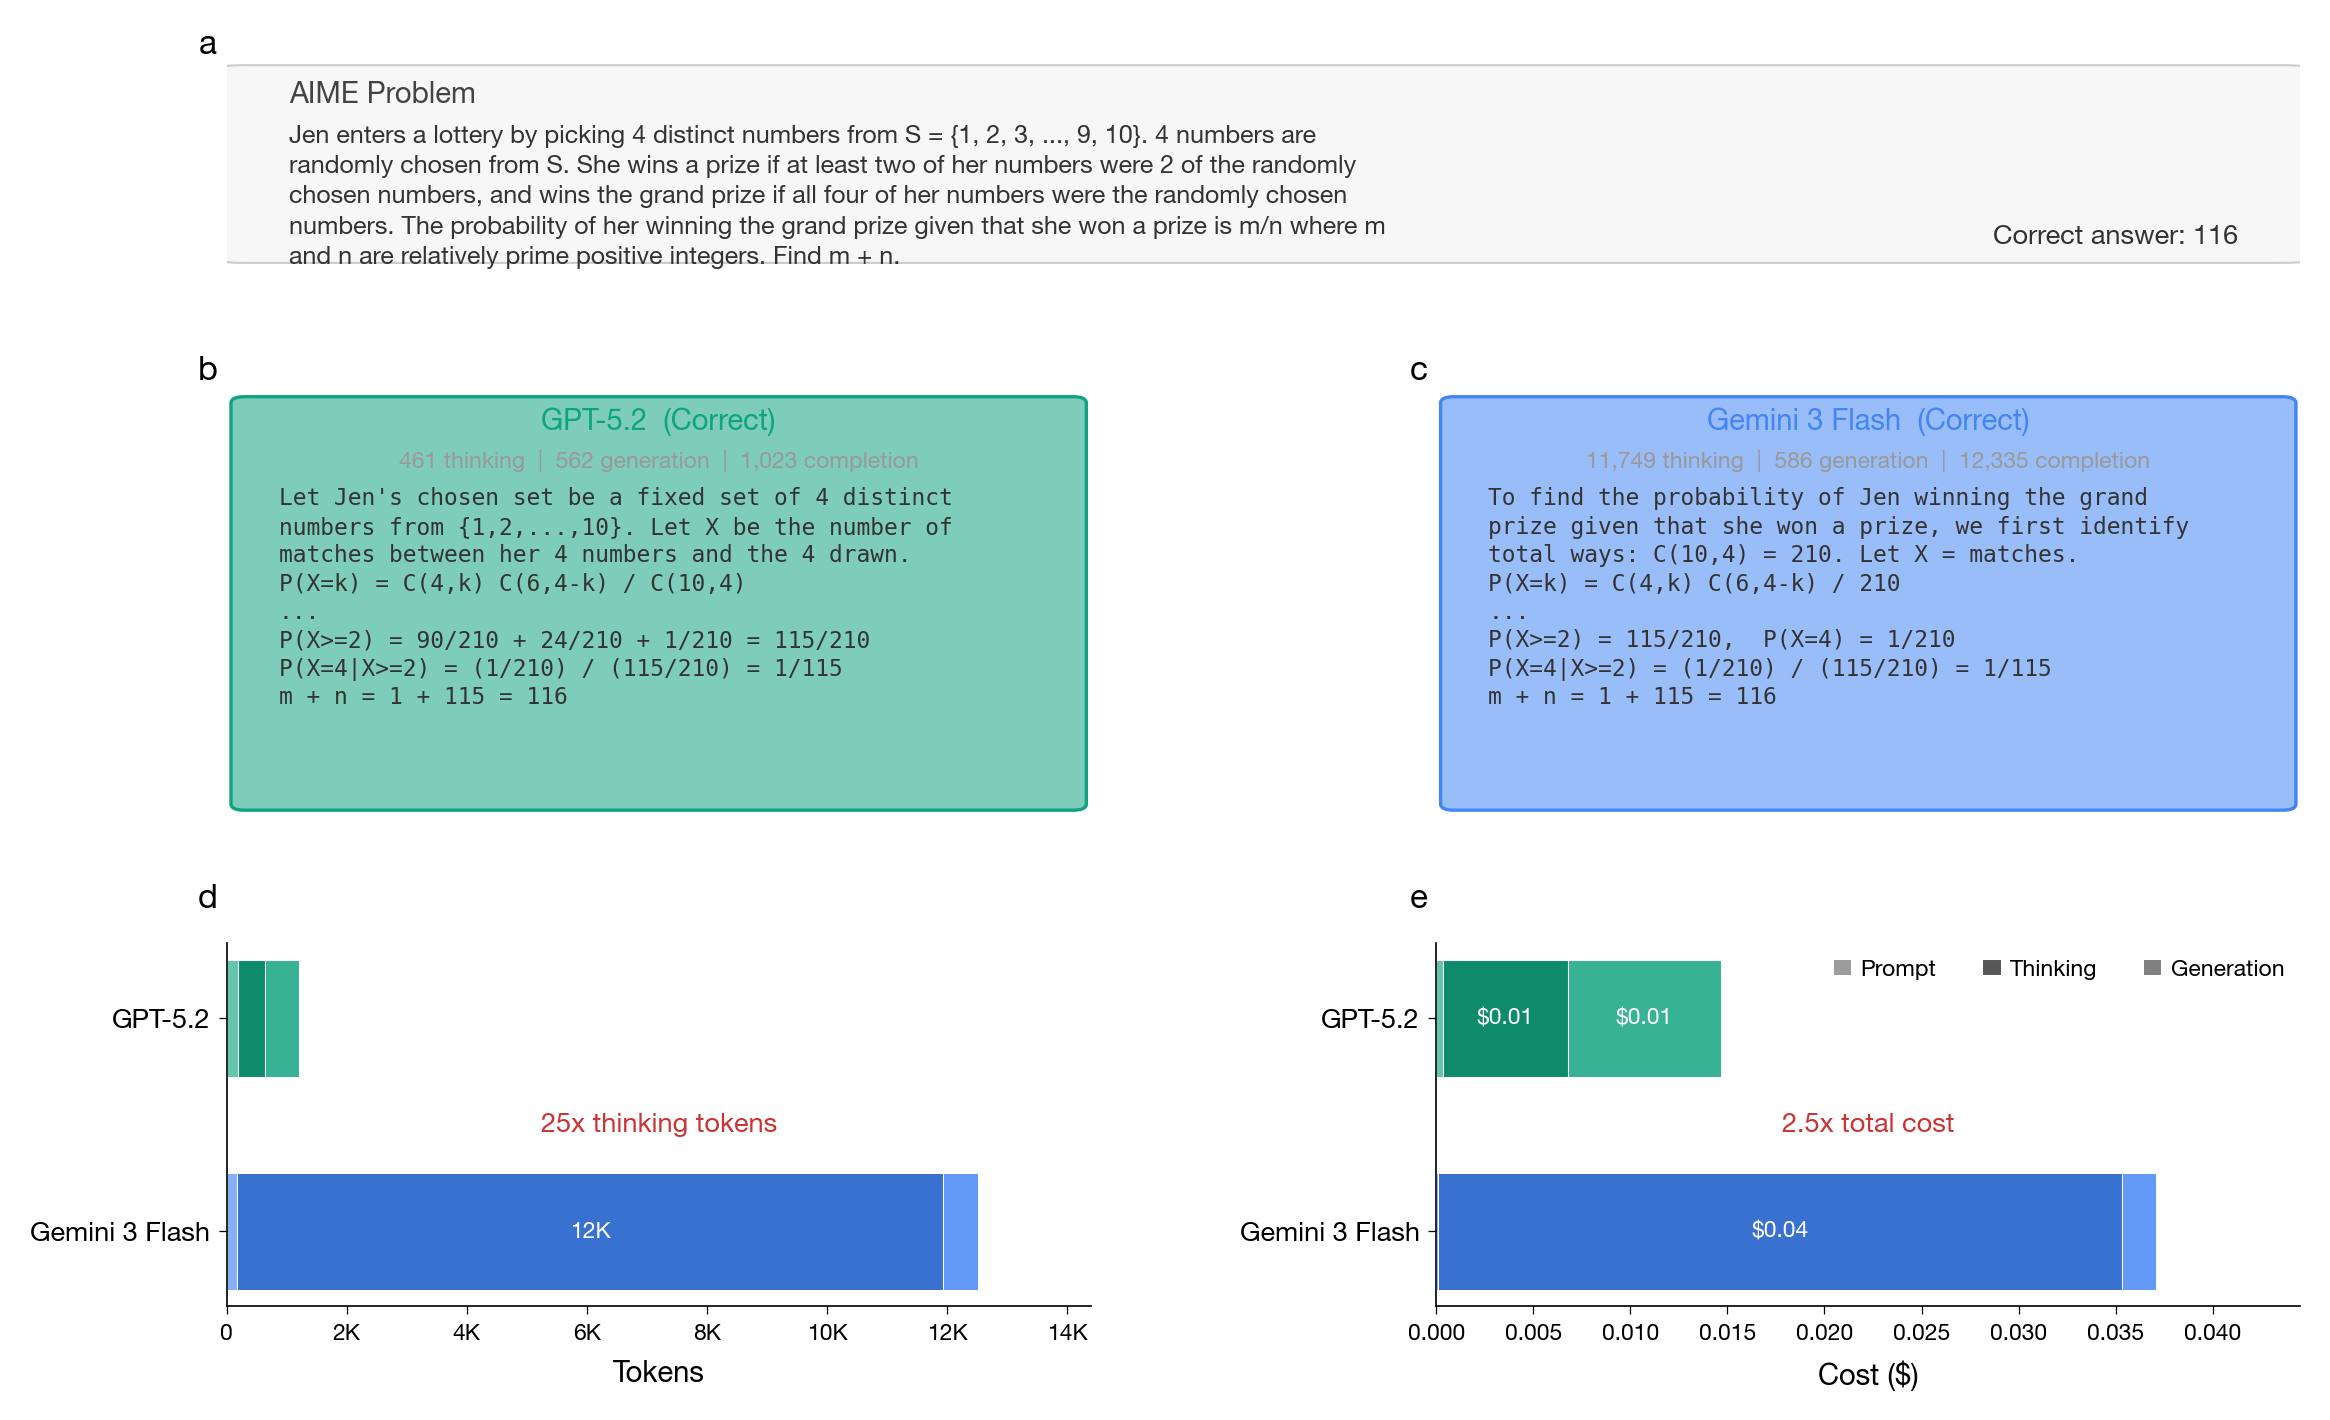

Saved to figure/case_study_example.{pdf,png}


In [45]:
# ═══════════════════════════════════════════════════════════════════════
# Comprehensive Case-Study Figure: Question + Responses + Token/Cost
# ═══════════════════════════════════════════════════════════════════════
import textwrap
from matplotlib.patches import FancyBboxPatch

# ── Data (already loaded above) ──────────────────────────────────────
gpt = dict(
    prompt=_gpt_rec['prompt_tokens'],
    thinking=_gpt_rec['thinking_tokens'],
    generation=_gpt_rec['completion_tokens'] - _gpt_rec['thinking_tokens'],
    completion=_gpt_rec['completion_tokens'],
)
gem = dict(
    prompt=_gem_rec['prompt_tokens'],
    thinking=_gem_rec.get('thinking_tokens', 0),
    generation=_gem_rec['completion_tokens'] - _gem_rec.get('thinking_tokens', 0),
    completion=_gem_rec['completion_tokens'],
)
gpt_costs = dict(
    prompt=gpt['prompt'] * _gpt_price['input_price_per_MTok'] / 1e6,
    thinking=gpt['thinking'] * _gpt_price['output_price_per_MTok'] / 1e6,
    generation=gpt['generation'] * _gpt_price['output_price_per_MTok'] / 1e6,
)
gpt_costs['total'] = sum(gpt_costs.values())
gem_costs = dict(
    prompt=gem['prompt'] * _gem_price['input_price_per_MTok'] / 1e6,
    thinking=gem['thinking'] * _gem_price['output_price_per_MTok'] / 1e6,
    generation=gem['generation'] * _gem_price['output_price_per_MTok'] / 1e6,
)
gem_costs['total'] = sum(gem_costs.values())

# ── Condensed response excerpts (plain text) ─────────────────────────
gpt_response = (
    "Let Jen's chosen set be a fixed set of 4 distinct\n"
    "numbers from {1,2,...,10}. Let X be the number of\n"
    "matches between her 4 numbers and the 4 drawn.\n"
    "P(X=k) = C(4,k) C(6,4-k) / C(10,4)\n"
    "...\n"
    "P(X>=2) = 90/210 + 24/210 + 1/210 = 115/210\n"
    "P(X=4|X>=2) = (1/210) / (115/210) = 1/115\n"
    "m + n = 1 + 115 = 116"
)
gem_response = (
    "To find the probability of Jen winning the grand\n"
    "prize given that she won a prize, we first identify\n"
    "total ways: C(10,4) = 210. Let X = matches.\n"
    "P(X=k) = C(4,k) C(6,4-k) / 210\n"
    "...\n"
    "P(X>=2) = 115/210,  P(X=4) = 1/210\n"
    "P(X=4|X>=2) = (1/210) / (115/210) = 1/115\n"
    "m + n = 1 + 115 = 116"
)

# ── Figure ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(DOUBLE_COL, 4.6))
gs = gridspec.GridSpec(
    3, 2,
    height_ratios=[0.55, 1.15, 1.0],
    hspace=0.40, wspace=0.40,
    left=0.01, right=0.97, top=0.97, bottom=0.07,
)

# ── Panel (a): Question ──────────────────────────────────────────────
ax_q = fig.add_subplot(gs[0, :])
ax_q.set_xlim(0, 1); ax_q.set_ylim(0, 1); ax_q.axis('off')

q_text = (
    "Jen enters a lottery by picking 4 distinct numbers from "
    "S = {1, 2, 3, ..., 9, 10}. 4 numbers are randomly chosen from S. "
    "She wins a prize if at least two of her numbers were 2 of the randomly "
    "chosen numbers, and wins the grand prize if all four of her numbers were "
    "the randomly chosen numbers. The probability of her winning the grand "
    "prize given that she won a prize is m/n where m and n are relatively prime "
    "positive integers. Find m + n."
)
q_wrapped = textwrap.fill(q_text, width=100)

q_box = FancyBboxPatch(
    (0.01, 0.02), 0.98, 0.96,
    boxstyle="round,pad=0.015",
    facecolor='#F7F7F7', edgecolor='#CCCCCC', linewidth=0.5,
    transform=ax_q.transAxes, zorder=0,
)
ax_q.add_patch(q_box)
ax_q.text(0.03, 0.92, 'AIME Problem', transform=ax_q.transAxes,
          fontsize=7, fontweight='bold', va='top', color='#444444')
ax_q.text(0.03, 0.70, q_wrapped, transform=ax_q.transAxes,
          fontsize=6, va='top', ha='left', linespacing=1.4,
          style='italic', color='#333333')
ax_q.text(0.97, 0.08, 'Correct answer: 116', transform=ax_q.transAxes,
          fontsize=6.5, fontweight='bold', va='bottom', ha='right',
          color='#333333')
ax_q.text(-0.005, 1.02, 'a', transform=ax_q.transAxes, **PANEL_KW)

# ── Helper for response panels ───────────────────────────────────────
def _draw_response(ax, model_name, provider, response_text,
                   thinking_tok, gen_tok, total_comp, panel_label):
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
    base_color = PROVIDER_COLORS.get(provider, '#888888')
    bg_color = shade(base_color, 1.85)

    box = FancyBboxPatch(
        (0.02, 0.02), 0.96, 0.96,
        boxstyle="round,pad=0.015",
        facecolor=bg_color, edgecolor=base_color, linewidth=0.8,
        transform=ax.transAxes, zorder=0,
    )
    ax.add_patch(box)

    ax.text(0.50, 0.97, f'{model_name}  (Correct)',
            transform=ax.transAxes, fontsize=7, fontweight='bold',
            va='top', ha='center', color=base_color)
    ax.text(0.50, 0.87,
            f'{thinking_tok:,} thinking  |  {gen_tok:,} generation  |  '
            f'{total_comp:,} completion',
            transform=ax.transAxes, fontsize=5.5, va='top', ha='center',
            color='#999999')
    ax.text(0.06, 0.78, response_text, transform=ax.transAxes,
            fontsize=5.5, va='top', ha='left', family='monospace',
            linespacing=1.3, color='#333333')
    ax.text(-0.01, 1.02, panel_label, transform=ax.transAxes, **PANEL_KW)

# ── Panel (b): GPT-5.2 Response ─────────────────────────────────────
ax_b = fig.add_subplot(gs[1, 0])
_draw_response(ax_b, 'GPT-5.2', 'OpenAI', gpt_response,
               gpt['thinking'], gpt['generation'], gpt['completion'], 'b')

# ── Panel (c): Gemini 3 Flash Response ──────────────────────────────
ax_c = fig.add_subplot(gs[1, 1])
_draw_response(ax_c, 'Gemini 3 Flash', 'Google', gem_response,
               gem['thinking'], gem['generation'], gem['completion'], 'c')

# ── Panel (d): Token bars  |  Panel (e): Cost bars ──────────────────
ax_tok  = fig.add_subplot(gs[2, 0])
ax_cost = fig.add_subplot(gs[2, 1])

models_cs   = ['GPT-5.2', 'Gemini 3 Flash']
providers_cs = ['OpenAI', 'Google']
y = np.array([0.0, 1.0])
bar_h = 0.55

# --- Token bars (panel d) ---
tok_vals = [
    [gpt['prompt'], gpt['thinking'], gpt['generation']],
    [gem['prompt'], gem['thinking'], gem['generation']],
]
max_tok = max(sum(tv) for tv in tok_vals)

for i in range(2):
    left = 0.0
    for si in range(3):
        v = tok_vals[i][si]
        c = provider_shades(providers_cs[i])[si]
        ax_tok.barh(y[i], v, left=left, height=bar_h,
                    color=c, edgecolor='white', linewidth=0.25)
        if v / max_tok > 0.05:
            ax_tok.text(left + v / 2, y[i], _fmt_tokens(v),
                        ha='center', va='center', fontsize=5.5,
                        color='white', fontweight='bold')
        left += v

# Thinking ratio annotation between bars
think_ratio = gem['thinking'] / gpt['thinking']
ax_tok.text(0.50, 0.50, f'{think_ratio:.0f}x thinking tokens',
            transform=ax_tok.transAxes,
            fontsize=6.5, fontweight='bold', color='#CC3333',
            ha='center', va='center')

ax_tok.set_yticks(y)
ax_tok.set_yticklabels(models_cs, fontsize=6.5)
ax_tok.invert_yaxis()
ax_tok.set_xlabel('Tokens', fontsize=7)
ax_tok.xaxis.set_major_formatter(plt.FuncFormatter(
    lambda x, _: f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'
))
ax_tok.tick_params(axis='x', labelsize=5.5)
ax_tok.set_xlim(right=max_tok * 1.15)
ax_tok.text(-0.01, 1.08, 'd', transform=ax_tok.transAxes, **PANEL_KW)

# --- Cost bars (panel e) ---
cost_vals = [
    [gpt_costs['prompt'], gpt_costs['thinking'], gpt_costs['generation']],
    [gem_costs['prompt'], gem_costs['thinking'], gem_costs['generation']],
]
max_cost = max(sum(cv) for cv in cost_vals)

for i in range(2):
    left = 0.0
    for si in range(3):
        v = cost_vals[i][si]
        c = provider_shades(providers_cs[i])[si]
        ax_cost.barh(y[i], v, left=left, height=bar_h,
                     color=c, edgecolor='white', linewidth=0.25)
        if v / max_cost > 0.08:
            ax_cost.text(left + v / 2, y[i], _fmt_cost(v),
                         ha='center', va='center', fontsize=5.5,
                         color='white', fontweight='bold')
        left += v

# Cost ratio annotation
cost_ratio = gem_costs['total'] / gpt_costs['total']
ax_cost.text(0.50, 0.50, f'{cost_ratio:.1f}x total cost',
             transform=ax_cost.transAxes,
             fontsize=6.5, fontweight='bold', color='#CC3333',
             ha='center', va='center')

ax_cost.set_yticks(y)
ax_cost.set_yticklabels(models_cs, fontsize=6.5)
ax_cost.invert_yaxis()
ax_cost.set_xlabel('Cost ($)', fontsize=7)
ax_cost.tick_params(axis='x', labelsize=5.5)
ax_cost.set_xlim(right=max_cost * 1.20)
ax_cost.text(-0.01, 1.08, 'e', transform=ax_cost.transAxes, **PANEL_KW)

# Shared legend — upper right of panel e (empty space there)
grey = '#666666'
legend_handles = [
    Patch(facecolor=shade(grey, SHADE_PROMPT),     edgecolor='white', linewidth=0.25, label='Prompt'),
    Patch(facecolor=shade(grey, SHADE_THINKING),   edgecolor='white', linewidth=0.25, label='Thinking'),
    Patch(facecolor=shade(grey, SHADE_GENERATION), edgecolor='white', linewidth=0.25, label='Generation'),
]
ax_cost.legend(handles=legend_handles, loc='upper right', frameon=False,
               ncol=3, fontsize=5.5)

fig.patch.set_alpha(0)
fig.savefig(PROJECT_ROOT / 'figure' / 'case_study_example.pdf',
            bbox_inches='tight', pad_inches=0.02, facecolor='none')
fig.savefig(PROJECT_ROOT / 'figure' / 'case_study_example.png',
            bbox_inches='tight', pad_inches=0.02, facecolor='none', dpi=600)
plt.show()
print('Saved to figure/case_study_example.{pdf,png}')

## 8. Per-Dataset Ranking Inversions: Listed Price vs Actual Cost

Slope charts showing how the ranking by listed price ($ per MTok) can invert when
actual cost is computed per dataset — revealing that cheaper-per-token models may
cost more in practice due to heavier thinking-token usage.

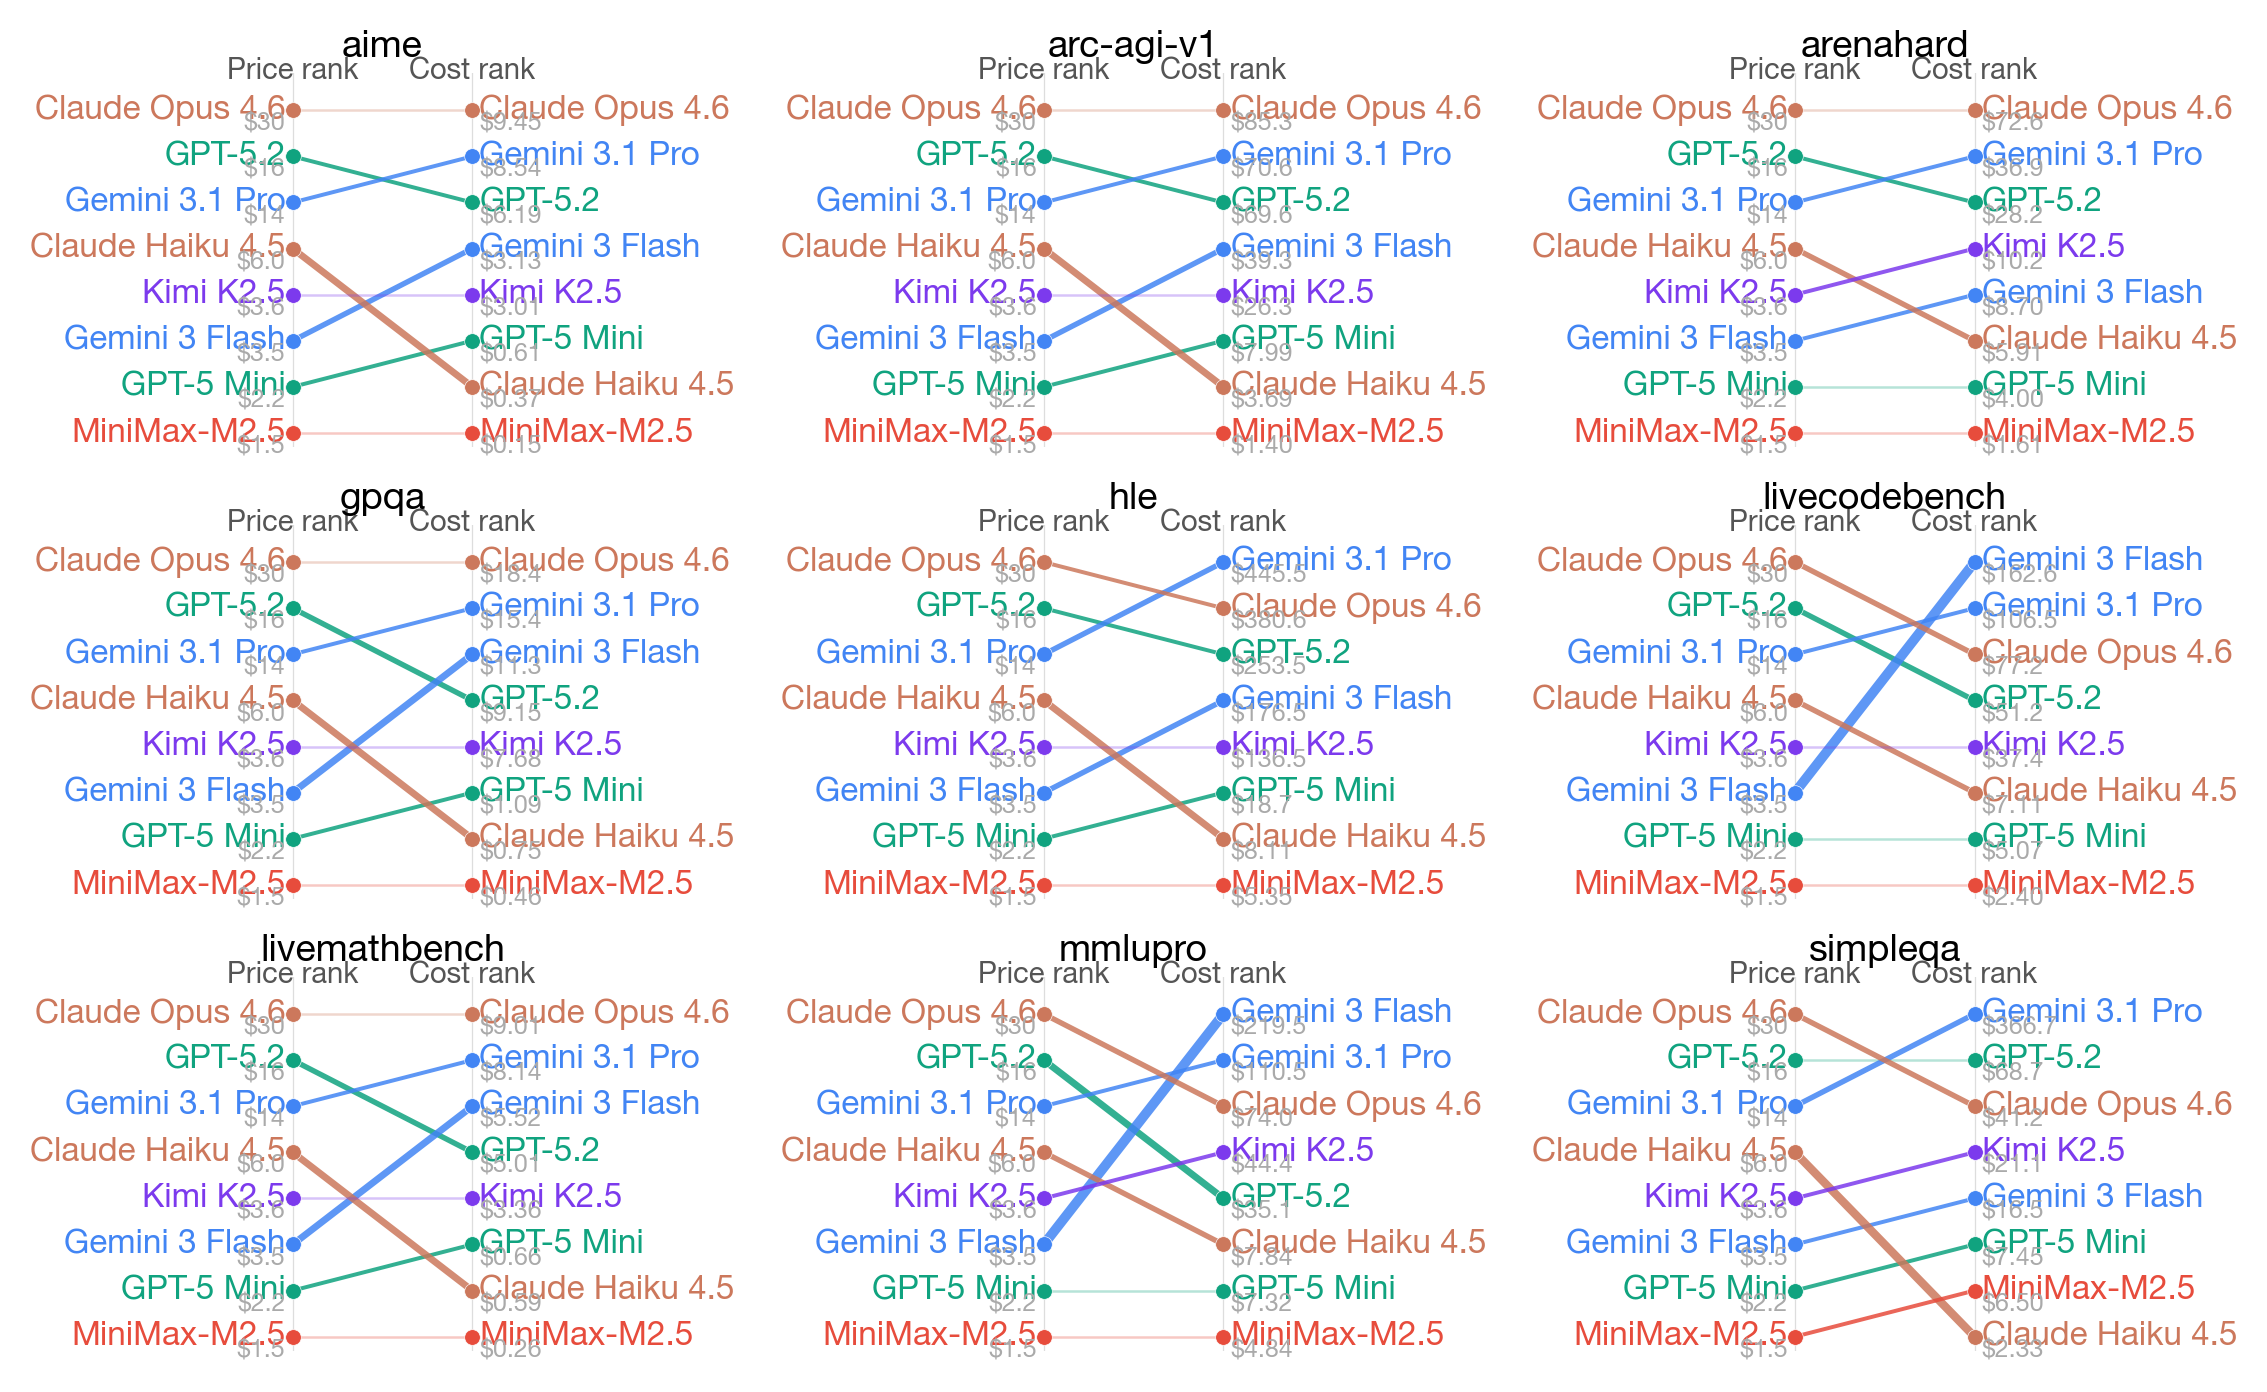

Saved to figure/ranking_inversion_per_dataset.{pdf,png}


In [37]:
# ═══════════════════════════════════════════════════════════════════════
# Per-dataset ranking inversion slope charts  (double-column, Nature)
# ═══════════════════════════════════════════════════════════════════════

def draw_slope_chart(ax, sub_df, title=None, fs_name=8, fs_val=6):
    """
    Compact slope chart: listed-price rank (left) → actual-cost rank (right).
    """
    d = sub_df.copy()
    d['listed_blended'] = d['input_price'] + d['output_price']
    d['price_rank'] = d['listed_blended'].rank(method='first', ascending=False).astype(int)
    d['cost_rank']  = d['total_cost'].rank(method='first', ascending=False).astype(int)
    n = len(d)

    x_left, x_right = 0, 1.0
    ax.set_xlim(-0.55, 1.55)
    # Tighter y range
    ax.set_ylim(0.2, n + 0.3)
    ax.invert_yaxis()

    for _, row in d.iterrows():
        pr, cr = row['price_rank'], row['cost_rank']
        color = PROVIDER_COLORS.get(row['provider'], '#888888')
        delta = abs(pr - cr)
        lw = 0.6 if delta == 0 else 0.6 + delta * 0.35
        alpha = 0.85 if delta > 0 else 0.30
        ax.plot([x_left, x_right], [pr, cr],
                color=color, lw=lw, alpha=alpha, zorder=2)

    for _, row in d.iterrows():
        pr, cr = row['price_rank'], row['cost_rank']
        name = row['short_name']
        color = PROVIDER_COLORS.get(row['provider'], '#888888')
        blended = row['listed_blended']
        cost = row['total_cost']

        price_str = f"${blended:.0f}" if blended >= 10 else f"${blended:.1f}"
        cost_str  = f"${cost:.1f}" if cost >= 10 else f"${cost:.2f}"

        ax.scatter(x_left, pr, s=14, color=color, zorder=4,
                   edgecolors='white', linewidths=0.15)
        ax.text(x_left - 0.04, pr, name,
                ha='right', va='center', fontsize=fs_name, fontweight='medium',
                color=color)
        ax.text(x_left - 0.04, pr + 0.30, price_str,
                ha='right', va='center', fontsize=fs_val, color='#AAAAAA')

        ax.scatter(x_right, cr, s=14, color=color, zorder=4,
                   edgecolors='white', linewidths=0.15)
        ax.text(x_right + 0.04, cr, name,
                ha='left', va='center', fontsize=fs_name, fontweight='medium',
                color=color)
        ax.text(x_right + 0.04, cr + 0.30, cost_str,
                ha='left', va='center', fontsize=fs_val, color='#AAAAAA')

    # Column headers — use title line to save vertical space
    if title:
        ax.set_title(f'{title}', fontsize=9, fontweight='bold', pad=4)

    ax.text(x_left, 0.45, 'Price rank', ha='center', va='bottom',
            fontsize=7, fontweight='bold', color='#555555')
    ax.text(x_right, 0.45, 'Cost rank', ha='center', va='bottom',
            fontsize=7, fontweight='bold', color='#555555')

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.axvline(x_left,  color='#DDDDDD', lw=0.3, zorder=0)
    ax.axvline(x_right, color='#DDDDDD', lw=0.3, zorder=0)


# ── Build grid ───────────────────────────────────────────────────────
datasets_slope = sorted(df_all['dataset'].unique())
n_ds = len(datasets_slope)
n_cols = 3
n_rows = int(np.ceil(n_ds / n_cols))
n_models = df_all['short_name'].nunique()

fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(DOUBLE_COL, n_rows * (n_models * 0.13 + 0.45)))

axes = axes.flatten()

for idx, ds_name in enumerate(datasets_slope):
    sub = df_all[df_all['dataset'] == ds_name].copy()
    draw_slope_chart(axes[idx], sub, title=ds_name)

for idx in range(n_ds, len(axes)):
    axes[idx].set_visible(False)

fig.patch.set_alpha(0)
plt.tight_layout(pad=0.15, h_pad=0.8, w_pad=3.5)
fig.savefig(PROJECT_ROOT / 'figure' / 'ranking_inversion_per_dataset.pdf',
            bbox_inches='tight', pad_inches=0.01, facecolor='none')
fig.savefig(PROJECT_ROOT / 'figure' / 'ranking_inversion_per_dataset.png',
            bbox_inches='tight', pad_inches=0.01, facecolor='none', dpi=600)
plt.show()
print('Saved to figure/ranking_inversion_per_dataset.{pdf,png}')